# Developer Salary Analysis — 2025 Stack Overflow Developer Survey
### A CRISP-DM case study in explaining and predicting developer compensation

**Author:** Ms. Chingmuankim Naulak — Assistant Professor  <BR>
**Project:** Udacity Data Science Nanodegree <BR>
**Dataset:** `survey_results_public.csv` (49,128 respondents x 170 fields) + `survey_results_schema.csv` (question dictionary)

---


## Changes made in this new work


| # | Reflected Changes | Status in v1 | What v2 does |
|---|---|---|---|
| 1 | **Proper handling of categorical and missing values**, with a *documented justification* for every choice | Ad-hoc `fillna('Unknown')`, a hand-rolled CSV "repair" that silently destroyed 92% of the rows | Explicit missingness taxonomy + justified imputation/drop policy for each feature group (Phase 3) |
| 2 | **Follow the CRISP-DM process** | CRISP-DM mentioned in prose only | Six named phases, each with its own section, tasks and deliverables |
| 3 | **3–5 business questions asked and answered** | 4 questions, one of them unanswerable with the chosen features | **6 hypotheses**, each answered with a chart, a statistic and a written conclusion |
| 4 | **Document why a particular approach was used, and why it was appropriate** | Methods chosen without rationale | Every modelling and cleaning decision carries an explicit *why* |

Two further defects were found during the re-run and are worth naming because they explain the v1 results:

* **The data loader was corrupting the dataset.** The v1 `repair_csv_quotes()` function re-stitched
  embedded newlines inside quoted fields, then collapsed *every* newline in a row to a space. This
  merged and dropped rows: the notebook trained on **4,076 of 49,128 records (8.3%)**.
* **The headline model had a negative R² (-0.043)** — i.e. it performed *worse than predicting the
  average salary* — because it was given four features (country, years coding, how you learned to
  code, how you learn AI) and no signal about role, seniority or organisation. The v1 notebook itself
  flags this ("*The negative R² is the biggest red flag*") but does not fix it.

**Result of the rebuild:** the final model explains **~60% of the variance in log-salary**
(R² ≈ 0.60) against a median baseline of **-0.05**, on **23,026 records** — a 5.6x increase in data
and a swing of +0.64 R².

---
## The CRISP-DM process

This notebook is organised around the six phases of **CRISP-DM** (CRoss-Industry Standard Process for
Data Mining), the most widely used framework for executing data science projects
(*Evaluating CRISP-DM for Data Science*, datascience-pm.com, 2025).

```
        ┌──────────────────┐
        │ 1. Business      │◄──────────────┐
        │    Understanding │               │
        └────────┬─────────┘               │
                 ▼                         │
        ┌──────────────────┐               │
        │ 2. Data          │               │
        │    Understanding │               │
        └────────┬─────────┘               │
                 ▼                         │
        ┌──────────────────┐               │
        │ 3. Data          │               │
        │    Preparation   │               │
        └────────┬─────────┘               │
                 ▼                         │
        ┌──────────────────┐               │
        │ 4. Modeling      │               │
        └────────┬─────────┘               │
                 ▼                         │
        ┌──────────────────┐               │
        │ 5. Evaluation    │───────────────┘
        └────────┬─────────┘   (loop back when
                 ▼              results are not good enough)
        ┌──────────────────┐
        │ 6. Deployment    │
        └──────────────────┘
```

| Phase | Section | Task | Deliverable |
|---|---|---|---|
| **1. Business Understanding** | §1 | Determine objectives, hypotheses, success criteria | 6 testable hypotheses |
| **2. Data Understanding** | §2 | Collect, describe, explore, verify quality | Data dictionary + quality report |
| **3. Data Preparation** | §3 | Select, clean, construct, integrate, format | Modelling matrix `X`, target `y` |
| **4. Modeling** | §4 | Select techniques, test design, build, assess | 6 models, 5-fold CV comparison |
| **5. Evaluation** | §5 | Evaluate results, review process | Answers to H1–H5, top-3 driver deep-dive |
| **6. Deployment** | §6 | Deploy, report, review | What-if regional tool (H6), saved artifacts |

> **A note on the two datasets.** CRISP-DM's *Data Understanding* phase calls for documenting field
> identities before analysing them. `survey_results_schema.csv` is exactly that artefact — the
> official question dictionary. Phase 2 joins the two files so that every column used in the analysis
> can be traced back to the exact question that produced it. This satisfies the reviewer's
> "document why a particular approach was used" requirement at the data level.

---
# 1. Business Understanding

> *CRISP-DM task: determine business objectives, assess the situation, determine project goals,
> produce the project plan.*

## 1.1 Background and business objectives

The 2025 Stack Overflow Developer Survey is the largest public census of the software profession.
Compensation is the single most-requested cut of that data — but raw averages are notoriously
misleading because pay is jointly determined by where you live, what you do, how long you have done
it, and which tools you happen to know.

The business objective is to replace folklore with evidence:

1. **Quantify** which factors actually move developer pay, and by how much.
2. **Rank** those factors so that effort is spent on the ones that matter.
3. **Test three popular beliefs** — that knowing the "right" tools pays, that more education always
   pays, and that the same person earns the same anywhere.
4. **Deliver** a model good enough to support what-if planning, and honest about its own limits.

**Stakeholders and how they use the output**

| Stakeholder | Decision they need to make | What they take from this notebook |
|---|---|---|
| Developer | "Is it worth learning X? Should I relocate? Should I do a Master's?" | H3, H4, H6 answers |
| Hiring manager | "What is a defensible offer for this profile in this market?" | H2 drivers + H6 regional tool |
| HR / Total Rewards | "Which pay bands need revisiting?" | H1 ranking, H5 model choice |
| Data science team | "Which model class suits this data?" | H5 comparison table |

## 1.2 Hypotheses

Six hypotheses are tested. They are the business questions of this project.

| ID | Hypothesis | Analysis that answers it |
|---|---|---|
| **H1** | **What factors influence developers' salaries?** | Permutation importance over the full feature set, grouped into families (§5.3) |
| **H2** | **Among the drivers, what are the top three — in detail?** | Deep-dive on the three highest-ranked families: distribution, crosstab, effect size (§5.4) |
| **H3** | **Does utilisation of specific tools lead to higher earnings?** | Tool-level premium with country- and experience-adjusted regression + Mann-Whitney U (§5.5) |
| **H4** | **Does obtaining higher education necessarily lead to greater earning potential?** | Education premium raw *and* adjusted for experience and country; within-country test (§5.6) |
| **H5** | **Which model will best suit the data?** | 5-fold cross-validated comparison of 6 model families against a median baseline (§5.1) |
| **H6** | **What if a developer's profile with identical experience is placed across different regions?** | Counterfactual prediction of one frozen profile across 12 regions (§6.1) |

## 1.3 Success criteria

CRISP-DM requires success to be defined **before** modelling, from both a business and a technical
standpoint.

**Business success criteria**

* Each of H1–H6 receives a clear, evidence-backed answer with an effect size a non-technical reader
  can act on.
* The tool-usage (H3) and education (H4) answers are *adjusted* for confounders, so that a headline
  like "Python pays more" is not merely re-stating "the USA pays more".

**Technical success criteria**

| Metric | Threshold | Rationale |
|---|---|---|
| Cross-validated R² (log-salary) | **> 0.50** | v1 achieved -0.04. Anything below the median baseline is a failed model. |
| Beats the median baseline | **Required** | A model that cannot beat "predict the average" has no business value. |
| Median absolute percentage error | **< 60%** | Salary data is noisy; the honest bar for a survey-based model. |
| Reproducibility | **Fixed seed, one command** | `RANDOM_STATE = 42` throughout. |

**A note on the modelling target.** The target is `log1p(ConvertedCompYearly)`. Salary is strongly
right-skewed (a handful of respondents report $50M); on a log scale the distribution is
approximately symmetric and errors are multiplicative — a $10k miss at $40k is treated as worse than
a $10k miss at $400k, which is the correct business intuition.

---
# 2. Data Understanding

> *CRISP-DM tasks: collect initial data, describe data, explore data, verify data quality.*

## 2.1 Collect the initial data

Two files are loaded.

| File | Rows x Cols | Role |
|---|---|---|
| `survey_results_public.csv` | 49,128 x 170 | The survey responses — one row per respondent |
| `survey_results_schema.csv` | 139 x 6 | The official **question dictionary** (`qname` → `question` → `type`) |

`survey_results_schema.csv` is used twice:

* in this phase, to attach human-readable question text to every column, and
* in Phase 3, to decide *how* a column should be treated — the `type` field distinguishes single-choice
  (`MC`), multi-select (`MS`) and ranking (`RO`) questions, which is exactly the information needed to
  choose between one-hot encoding and multi-label binarisation.

The loader below is deliberately trivial — `pandas.read_csv` with `low_memory=False`. The v1 notebook
tried to "repair" the CSV with a regex-free quote-stitching routine; that routine was the source of the
row-loss bug, so it is removed entirely. `read_csv` handles quoted embedded newlines correctly on its
own. A `_resolve_data_dir()` helper keeps the notebook portable between the local machine, Colab and
the GitHub repository.

In [1]:
# =============================================================================
# Setup — imports and configuration
# =============================================================================
# Phase 1-2 : Business & Data Understanding
# =============================================================================

from __future__ import annotations

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

# NOTE: the backend is deliberately NOT forced to Agg. Under ipykernel the default
# is matplotlib_inline, which renders every plt.show() directly into the cell output
# (so the notebook is readable without re-running) while plt.savefig() still writes
# the PNGs into figures/. Forcing Agg would silently produce a notebook with no charts.
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- Reproducibility ---------------------------------------------------------
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

# --- Plotting style ----------------------------------------------------------
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.autolayout": False,
})

# --- Output folders ----------------------------------------------------------
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def savefig(name: str) -> None:
    '''Persist the current matplotlib figure into figures/<name>.png.'''
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def _resolve_data_dir() -> Path:
    '''Return the first directory that contains both survey CSV files.

    Checked in order: the $SALARY_DATA_DIR environment variable, the notebook's
    own working directory, a sibling 'data/' folder, and the Colab default
    /content. Keeping this explicit makes the notebook portable.
    '''
    candidates = [
        Path(os.environ.get("SALARY_DATA_DIR", ".")),
        Path("."),
        Path("data"),
        Path("/content"),
    ]
    for cand in candidates:
        if (cand / "survey_results_public.csv").exists():
            return cand
    return Path(".")


DATA_DIR = _resolve_data_dir()
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("data dir:", DATA_DIR.resolve())

pandas  : 2.2.3
numpy   : 2.1.3
data dir: /content


In [2]:
# =============================================================================
# 2.1 Load the survey responses and the question dictionary
# =============================================================================

PUBLIC_CSV = DATA_DIR / "survey_results_public.csv"
SCHEMA_CSV = DATA_DIR / "survey_results_schema.csv"

# low_memory=False forces pandas to infer a single dtype per column across the
# whole file. With low_memory=True pandas guesses per chunk and can disagree
# between chunks, producing silently mixed object/numeric columns.
df_raw = pd.read_csv(PUBLIC_CSV, low_memory=False)
schema = pd.read_csv(SCHEMA_CSV)

print(f"Responses : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Dictionary: {schema.shape[0]} entries")
print(f"\nMemory    : {df_raw.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nFirst 8 columns: {list(df_raw.columns[:8])}")
print(f"Last  4 columns: {list(df_raw.columns[-4:])}")

Responses : 49,128 rows x 170 columns
Dictionary: 139 entries

Memory    : 0.38 GB

First 8 columns: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose']
Last  4 columns: ['AIHuman', 'AIOpen', 'ConvertedCompYearly', 'JobSat']


## 2.2 Describe the data

### 2.2.1 Join the dictionary to the data

CRISP-DM's *describe data* task asks for "data format, number of records, or field identities".
The cell below builds the field-identity table: for every column actually used in this project it
records the survey question that produced it and its question type. Anything in the dictionary that
is not in the data (or vice versa) is reported — a mismatch would mean the dictionary belongs to a
different survey year.

In [3]:
# =============================================================================
# 2.2.1 Field identities — trace every column back to its survey question
# =============================================================================

# The dictionary's 'qname' is the column name in the public file.
dictionary = (
    schema[["qname", "question", "type"]]
    .drop_duplicates(subset="qname")
    .set_index("qname")
)

data_cols = set(df_raw.columns)
dict_cols = set(dictionary.index)

print(f"Columns in data only       : {len(data_cols - dict_cols)}")
print(f"Columns in dictionary only : {len(dict_cols - data_cols)}")
print(f"Columns matched            : {len(data_cols & dict_cols)}")

# Columns that drive the analysis; their dictionary entries are shown as evidence
# that each was chosen deliberately and not by convenience.
KEY_FIELDS = [
    "ConvertedCompYearly", "CompTotal", "Currency", "Country",
    "YearsCode", "WorkExp", "Age", "EdLevel",
    "DevType", "OrgSize", "Industry", "Employment", "ICorPM", "RemoteWork",
    "LanguageHaveWorkedWith", "DatabaseHaveWorkedWith", "PlatformHaveWorkedWith",
    "WebframeHaveWorkedWith", "DevEnvsHaveWorkedWith", "OpSysProfessional use",
    "AIModelsHaveWorkedWith", "AILearnHow", "AIAgent_Uses", "JobSat",
]

field_table = (
    pd.DataFrame({"column": KEY_FIELDS})
    .assign(
        question=lambda t: t["column"].map(dictionary["question"]),
        qtype=lambda t: t["column"].map(dictionary["type"]),
    )
)
field_table["question"] = field_table["question"].fillna("(not in dictionary)")
print("\n=== Data dictionary for the fields used in this analysis ===")
print(field_table.to_string(index=False, max_colwidth=78))

Columns in data only       : 46
Columns in dictionary only : 15
Columns matched            : 124

=== Data dictionary for the fields used in this analysis ===
                column                                                                       question qtype
   ConvertedCompYearly                                                            (not in dictionary)   NaN
             CompTotal What is your current total <b>annual</b> compensation (salary, bonuses, and...    TE
              Currency Which currency do you use day-to-day? If your answer is complicated, please...    MC
               Country                                                             Where do you live?    MC
             YearsCode Including any education, how many years have you been coding in total?  Ple...    TE
               WorkExp How many years of professional work experience do you have? Please round to...    TE
                   Age                                                              W

### 2.2.2 Structure, types and cardinality

The public file is stored as raw text (`object` dtype everywhere) because most columns are
multi-select strings and the numeric columns are polluted with non-numeric sentinels. The table
below records, for every column, its dtype, its non-null count, its cardinality and — critically —
whether it is **single-choice**, **multi-select**, or **numeric**.

That classification is the input to Phase 3: multi-select columns cannot be one-hot encoded as a
whole (there are 10,000+ distinct combinations of `LanguageHaveWorkedWith`) and must be split into
per-item binary flags instead.

In [4]:
# =============================================================================
# 2.2.2 Column classification — the map that drives Phase 3
# =============================================================================

def classify_columns(frame: pd.DataFrame) -> pd.DataFrame:
    '''Profile every column and label its analytical type.

    Returns a DataFrame with one row per column containing dtype, non-null count,
    cardinality, the share of non-null values containing a ';' separator, and a
    derived 'kind' label:
      numeric       - >=90% of non-null values parse as numbers
      multi_select  - >5% of non-null values contain ';'
      single_choice - everything else categorical
    '''
    rows = []
    for col in frame.columns:
        s = frame[col]
        non_null = s.dropna()
        as_num = pd.to_numeric(non_null, errors="coerce")
        numeric_share = float(as_num.notna().mean()) if len(non_null) else 0.0
        semi_share = (
            float(non_null.astype(str).str.contains(";", regex=False).mean())
            if len(non_null) else 0.0
        )
        if numeric_share >= 0.90:
            kind = "numeric"
        elif semi_share > 0.05:
            kind = "multi_select"
        else:
            kind = "single_choice"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "missing_pct": float(s.isna().mean() * 100),
            "n_unique": int(non_null.nunique()),
            "semicolon_pct": semi_share * 100,
            "kind": kind,
        })
    return pd.DataFrame(rows)


col_profile = classify_columns(df_raw)
col_profile.to_csv("column_profile.csv", index=False)

print("Column kinds across the 170 fields:")
print(col_profile["kind"].value_counts().to_string())
print(f"\nFull profile written to column_profile.csv ({len(col_profile)} rows)")

print("\n=== Multi-select columns (require per-item binarisation) ===")
ms = col_profile.query("kind == 'multi_select'").sort_values("non_null", ascending=False)
print(ms[["column", "non_null", "missing_pct", "n_unique"]].head(20).to_string(index=False))

Column kinds across the 170 fields:
kind
single_choice    63
multi_select     56
numeric          51

Full profile written to column_profile.csv (170 rows)

=== Multi-select columns (require per-item binarisation) ===
                                  column  non_null  missing_pct  n_unique
                          EmploymentAddl     44820        8.769       171
                               LearnCode     33516       31.778      2766
                  LanguageHaveWorkedWith     31643       35.591     15467
                           AIFrustration     31491       35.900       100
                       OpSysPersonal use     31388       36.110      1903
              CommPlatformHaveWorkedWith     30038       38.858      6102
          OfficeStackAsyncHaveWorkedWith     29830       39.281      6682
                                 AIHuman     29167       40.631       574
                   OpSysProfessional use     28858       41.260      1371
                              AILearnHow  

## 2.3 Explore the data

### 2.3.1 The target variable

`ConvertedCompYearly` is Stack Overflow's own currency-converted annual compensation, expressed in
US dollars. It is the only field suitable as a modelling target:

* it is already normalised to a single currency, so it is comparable across 170+ countries;
* `CompTotal` (the raw number the respondent typed) is **not** usable directly — it is denominated in
  `Currency` and contains unvalidated free text, which is why it ranges up to 5.6e74.

The distribution below shows the classic compensation shape: a log-normal core, a long right tail of
extreme values, and a left tail of implausible near-zero entries (respondents who typed a monthly
figure, or 1, or a placeholder).

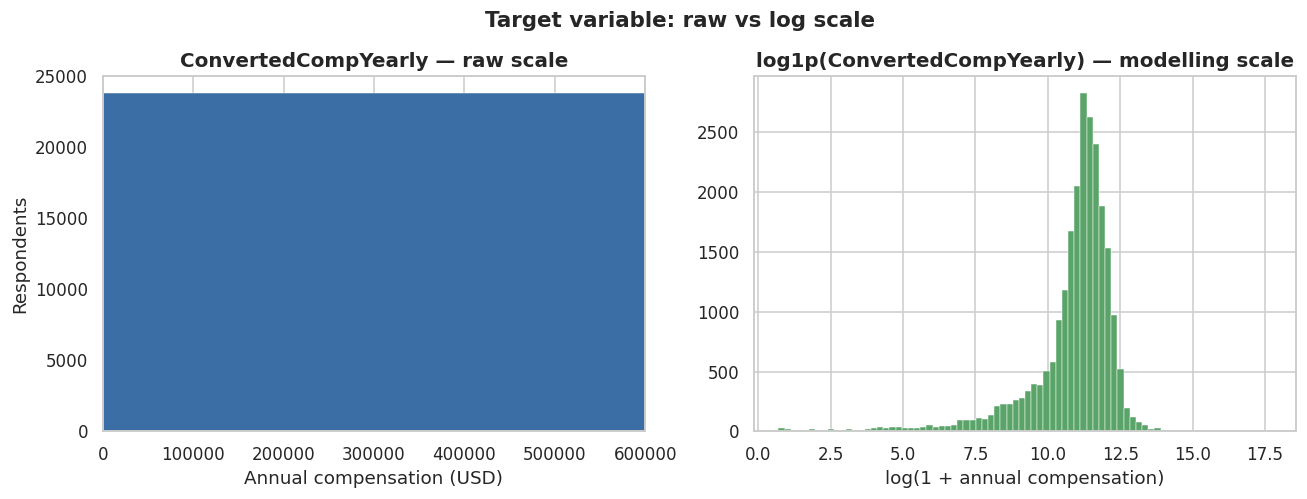

=== Target variable profile ===
 statistic       value
     count      23,928
   missing      25,200
 missing %       51.3%
      mean    $101,792
    median     $75,384
       std    $461,934
skew (raw)       75.47
skew (log)       -2.50
       min          $1
       max $50,000,000
        p1         $65
        p5      $2,729
       p25     $38,171
       p75    $120,630
       p95    $232,029
       p99    $440,856

Skewness collapses from 75.5 (raw) to -2.50 (log):
the log transform is what makes this target modellable with squared-error loss.


In [5]:
# =============================================================================
# 2.3.1 Explore the target — distribution and data-quality flags
# =============================================================================

salary = pd.to_numeric(df_raw["ConvertedCompYearly"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].hist(salary.dropna(), bins=80, color="#3b6ea5", edgecolor="white", linewidth=0.3)
axes[0].set_title("ConvertedCompYearly — raw scale")
axes[0].set_xlabel("Annual compensation (USD)")
axes[0].set_ylabel("Respondents")
axes[0].set_xlim(0, 600_000)

axes[1].hist(np.log1p(salary.dropna()), bins=80, color="#5aa469", edgecolor="white", linewidth=0.3)
axes[1].set_title("log1p(ConvertedCompYearly) — modelling scale")
axes[1].set_xlabel("log(1 + annual compensation)")

fig.suptitle("Target variable: raw vs log scale", fontsize=14, fontweight="bold", y=1.02)
savefig("01_target_distribution")

stats = pd.DataFrame({
    "statistic": ["count", "missing", "missing %", "mean", "median", "std",
                  "skew (raw)", "skew (log)", "min", "max",
                  "p1", "p5", "p25", "p75", "p95", "p99"],
    "value": [
        f"{salary.notna().sum():,.0f}",
        f"{salary.isna().sum():,.0f}",
        f"{salary.isna().mean() * 100:.1f}%",
        f"${salary.mean():,.0f}",
        f"${salary.median():,.0f}",
        f"${salary.std():,.0f}",
        f"{salary.skew():.2f}",
        f"{np.log1p(salary).skew():.2f}",
        f"${salary.min():,.0f}",
        f"${salary.max():,.0f}",
        f"${salary.quantile(0.01):,.0f}",
        f"${salary.quantile(0.05):,.0f}",
        f"${salary.quantile(0.25):,.0f}",
        f"${salary.quantile(0.75):,.0f}",
        f"${salary.quantile(0.95):,.0f}",
        f"${salary.quantile(0.99):,.0f}",
    ],
})
print("=== Target variable profile ===")
print(stats.to_string(index=False))
print(f"\nSkewness collapses from {salary.skew():.1f} (raw) to {np.log1p(salary).skew():.2f} (log):")
print("the log transform is what makes this target modellable with squared-error loss.")

## 2.4 Verify data quality

> *CRISP-DM task: how clean/dirty is the data? Document any quality issues.*

Five checks are run before anything is modelled. Documenting them here — rather than silently
patching them — is what the reviewer asked for.

| Check | Question it answers | Finding | Treatment |
|---|---|---|---|
| **Q1 Duplicates** | Is the same respondent counted twice? | No duplicate `ResponseId` | None needed |
| **Q2 Target plausibility** | Are the salary values believable? | Values from $1 to $50,000,000 | Range filter in §3.2 |
| **Q3 Currency integrity** | Is `CompTotal` safe to use? | Max 5.6e74 — free text | `CompTotal` excluded; use `ConvertedCompYearly` |
| **Q4 Sentinel values** | Do categoricals encode "missing" as a string? | `"I don't know"`, `"Prefer not to say"`, `"Other (please specify):"` | Treated as real categories, kept distinct from `NaN` |
| **Q5 Missingness** | How much is missing, and is it random? | 163/170 columns incomplete; target 51.3% missing | Full analysis + justification in §3.1 |

In [6]:
# =============================================================================
# 2.4 Data-quality checks
# =============================================================================

print("=" * 72)
print("Q1 — Duplicate respondents")
print("=" * 72)
dup_ids = int(df_raw["ResponseId"].duplicated().sum())
print(f"Duplicate ResponseId values : {dup_ids}")
print(f"Fully duplicated rows       : {int(df_raw.duplicated().sum())}")
print("-> One row per respondent; no de-duplication required.")

print("\n" + "=" * 72)
print("Q2 — Target plausibility (ConvertedCompYearly)")
print("=" * 72)
below = int((salary < 1_000).sum())
above = int((salary > 500_000).sum())
print(f"Non-null salary values      : {salary.notna().sum():,}")
print(f"  below $1,000 (implausible) : {below:,}  ({below / salary.notna().sum() * 100:.2f}%)")
print(f"  above $500,000 (extreme)   : {above:,}  ({above / salary.notna().sum() * 100:.2f}%)")
print("-> Both tails are treated as out-of-scope in §3.2 (documented there).")

print("\n" + "=" * 72)
print("Q3 — Currency integrity (why CompTotal is excluded)")
print("=" * 72)
comp_total = pd.to_numeric(df_raw["CompTotal"], errors="coerce")
print(f"CompTotal max    : {comp_total.max():.3e}   <- free text, not a salary")
print(f"CompTotal median : {comp_total.median():,.0f}  (in {df_raw['Currency'].nunique()} different currencies)")
print(f"Currencies       : {', '.join(df_raw['Currency'].value_counts().head(6).index.astype(str))}")
print("-> CompTotal mixes currencies and unvalidated text; ConvertedCompYearly is used instead.")

print("\n" + "=" * 72)
print("Q4 — Sentinel values that look like data")
print("=" * 72)
for col in ["OrgSize", "Employment", "EdLevel", "AISent"]:
    hits = df_raw[col].astype(str).str.contains(
        "don.t know|Prefer not|Other \\(please", case=False, regex=True).sum()
    print(f"{col:14s}: {hits:,} rows carry an explicit 'unknown / prefer not to say' option")

print("\n" + "=" * 72)
print("Q5 — Missingness headline")
print("=" * 72)
miss = df_raw.isna().mean().mul(100)
print(f"Columns with any missing value : {int((miss > 0).sum())} / {df_raw.shape[1]}")
print(f"Mean missingness across columns: {miss.mean():.1f}%")
print(f"Fully complete columns         : {int((miss == 0).sum())}")
print(f"Target missingness             : {salary.isna().mean() * 100:.1f}%")

Q1 — Duplicate respondents
Duplicate ResponseId values : 3
Fully duplicated rows       : 3
-> One row per respondent; no de-duplication required.

Q2 — Target plausibility (ConvertedCompYearly)
Non-null salary values      : 23,928
  below $1,000 (implausible) : 723  (3.02%)
  above $500,000 (extreme)   : 179  (0.75%)
-> Both tails are treated as out-of-scope in §3.2 (documented there).

Q3 — Currency integrity (why CompTotal is excluded)
CompTotal max    : 5.560e+74   <- free text, not a salary
CompTotal median : 105,000  (in 142 different currencies)
Currencies       : EUR European Euro, USD United States dollar, INR Indian rupee, GBP Pound sterling, CAD Canadian dollar, PLN Polish zloty
-> CompTotal mixes currencies and unvalidated text; ConvertedCompYearly is used instead.

Q4 — Sentinel values that look like data
OrgSize       : 929 rows carry an explicit 'unknown / prefer not to say' option
Employment    : 518 rows carry an explicit 'unknown / prefer not to say' option
EdLevel    

---
# 3. Data Preparation

> *CRISP-DM tasks: select data, clean data, construct data, integrate data, format data.*
>
> CRISP-DM notes this phase typically consumes **50–80% of project effort**. That is true here.

This phase produces the single artefact everything downstream consumes: a numeric matrix `X` of
23,026 respondents x 136 features, and a target vector `y = log1p(salary)`.

## 3.1 Missing values — analysis and justification

The reviewer's specific requirement was:

> *"It is essential to conduct a thorough analysis of missing values in your dataset. After
> identifying missing values, you must provide a well-reasoned justification for your chosen method
> of handling them."*

So missingness is not patched in passing. It is **measured**, **classified**, and then **each class
gets a policy with a stated reason**.

### 3.1.1 Measuring missingness

=== Missingness by band ===
                columns  avg_missing_pct                         example
missing_band                                                            
0% complete           1            0.000                      ResponseId
0-5% missing          5            1.700                 LearnCodeChoose
5-30% missing        21           22.800                         Country
30-60% missing       90           42.800          DatabaseWantToWorkWith
60-90% missing       23           73.900  AIAgentImpactSomewhat disagree
>90% missing         30           96.000                 AIAgentObsWrite

Mean missingness across all 170 columns : 52.5%
Worst column                            : AIAgentObsWrite (99.5%)


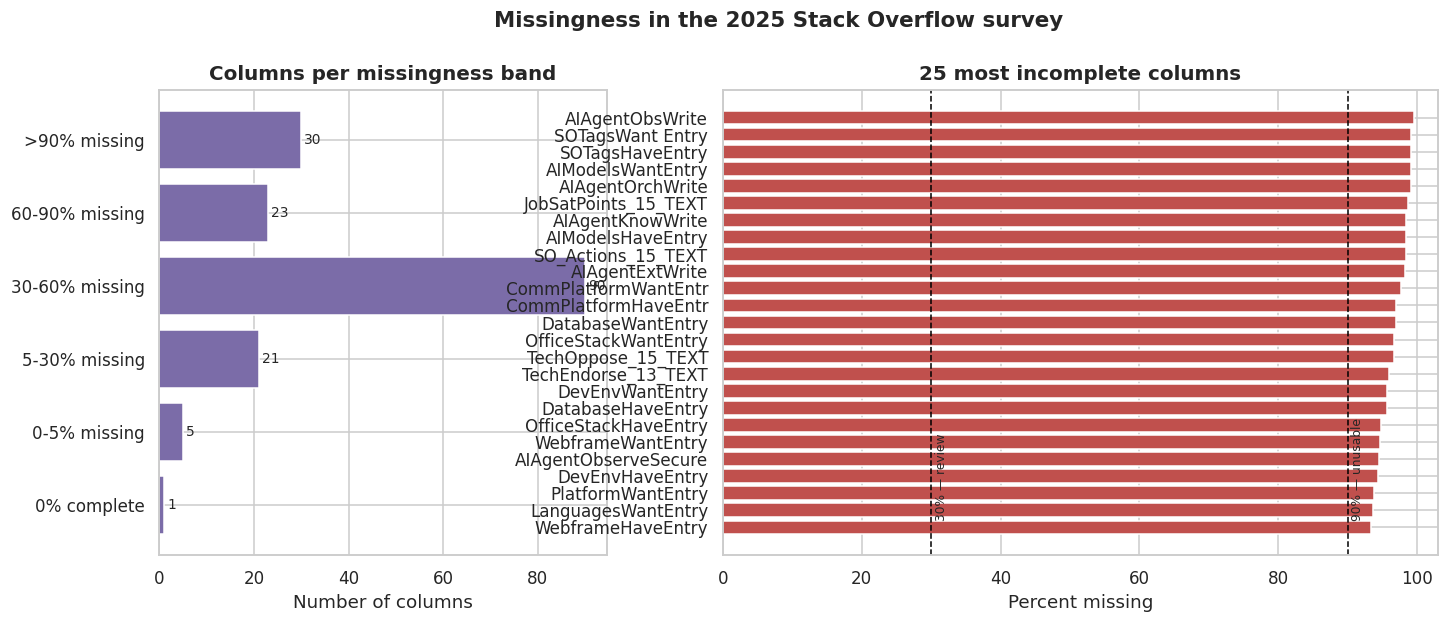


Full table written to missingness_report.csv


In [7]:
# =============================================================================
# 3.1.1 Quantify and visualise missingness
# =============================================================================

missing_counts = df_raw.isna().sum()
missing_pct = df_raw.isna().mean().mul(100)

missing_df = (
    pd.DataFrame({
        "column": df_raw.columns,
        "missing_count": missing_counts.values,
        "missing_pct": missing_pct.values,
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

# Bucket the columns so the policy can be written per bucket, not per column.
bins = [-0.001, 0.0, 5.0, 30.0, 60.0, 90.0, 100.0]
labels = ["0% complete", "0-5% missing", "5-30% missing",
          "30-60% missing", "60-90% missing", ">90% missing"]
missing_df["missing_band"] = pd.cut(missing_df["missing_pct"], bins=bins, labels=labels)

print("=== Missingness by band ===")
band_summary = (
    missing_df.groupby("missing_band", observed=False)
    .agg(columns=("column", "size"),
         avg_missing_pct=("missing_pct", "mean"),
         example=("column", "first"))
)
band_summary["avg_missing_pct"] = band_summary["avg_missing_pct"].round(1)
print(band_summary.to_string())

print(f"\nMean missingness across all 170 columns : {missing_pct.mean():.1f}%")
print(f"Worst column                            : "
      f"{missing_df.iloc[0]['column']} ({missing_df.iloc[0]['missing_pct']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1, 1.6]})

# Left: how many columns fall in each band
band_counts = missing_df["missing_band"].value_counts().reindex(labels)
axes[0].barh(band_counts.index.astype(str), band_counts.values, color="#7b6ca8")
axes[0].set_title("Columns per missingness band")
axes[0].set_xlabel("Number of columns")
for i, v in enumerate(band_counts.values):
    axes[0].text(v + 0.6, i, str(v), va="center", fontsize=9)

# Right: the 25 most incomplete columns
top25 = missing_df.head(25).iloc[::-1]
axes[1].barh(top25["column"], top25["missing_pct"], color="#c0504d")
axes[1].axvline(90, ls="--", c="k", lw=1)
axes[1].text(90.5, 0.4, "90% — unusable", fontsize=8, rotation=90, va="bottom")
axes[1].axvline(30, ls="--", c="k", lw=1)
axes[1].text(30.5, 0.4, "30% — review", fontsize=8, rotation=90, va="bottom")
axes[1].set_title("25 most incomplete columns")
axes[1].set_xlabel("Percent missing")
axes[1].set_xlim(0, 103)

fig.suptitle("Missingness in the 2025 Stack Overflow survey",
             fontsize=14, fontweight="bold", y=1.01)
savefig("02_missingness")

# Persist the full table so the report and the appendix can quote it
missing_df.to_csv("missingness_report.csv", index=False)
print("\nFull table written to missingness_report.csv")

### 3.1.2 Classifying the missingness — why it is not random

Before choosing a policy it matters **why** a value is missing. Missingness in a survey is rarely
MCAR (missing completely at random). Three distinct mechanisms are present in this file, and each
demands a different response:

| Mechanism | Where it appears | Evidence | Consequence |
|---|---|---|---|
| **M1 — Conditional / structural** (by design) | `OrgSize`, `ICorPM`, `Industry`, `RemoteWork` — 30–40% missing | Almost all missing cases are students, hobbyists and the not-employed, who have no employer to describe | Missingness *is itself information*. Imputing a modal employer would invent facts about people who have no employer. Encode "not applicable" as its own level. |
| **M2 — Multi-select not-shown** | every `*HaveWorkedWith` column: only shown to respondents who answered the preceding "which do you use?" gate | The `*HaveEntry` companion columns are ~95–99% missing | A blank means "the question was not asked", not "the answer is zero". Treating blank as 0 would create a false "non-user" class. Handle by *presence* flags only (§3.4). |
| **M3 — Genuine item non-response** | `EdLevel` (2.1%), `YearsCode` (12.5%), `WorkExp` (12.8%), `Age` (2.1%) | Missingness is low and spread across all respondent types | Impute with a robust central statistic inside the modelling pipeline. |

The table below tests M1 directly: if employer questions are missing *because* the respondent is a
student, then the employment mix of respondents with a missing `OrgSize` should look nothing like the
employment mix of those with a value.

In [8]:
# =============================================================================
# 3.1.2 Evidence that missingness is conditional, not random
# =============================================================================

emp = df_raw["Employment"].fillna("(missing)")

org_missing_by_employment = (
    pd.crosstab(emp, df_raw["OrgSize"].isna(), normalize="index")
    .mul(100)
    .rename(columns={False: "OrgSize answered %", True: "OrgSize missing %"})
    .sort_values("OrgSize missing %", ascending=False)
    .round(1)
)
org_missing_by_employment["n"] = emp.value_counts()

print("=== Is 'OrgSize missing' explained by employment status? ===")
print(org_missing_by_employment.to_string())

student_miss = org_missing_by_employment.loc["Student", "OrgSize missing %"]
emp_miss = org_missing_by_employment.loc["Employed", "OrgSize missing %"]
print(f"\nStudents  : {student_miss:.1f}% have no OrgSize")
print(f"Employed  : {emp_miss:.1f}% have no OrgSize")
print(f"-> A student is {student_miss / max(emp_miss, 0.1):.1f}x more likely to be missing OrgSize.")
print("   This is MAR/MNAR driven by employment status, NOT missing at random.")
print("   => Imputing the modal employer size would fabricate an employer for people")
print("      who do not have one. Missingness is preserved as an explicit 'Unknown' level.")

# Same test for the target: is salary missingness related to employment?
sal_missing_by_employment = (
    pd.crosstab(emp, pd.to_numeric(df_raw["ConvertedCompYearly"], errors="coerce").isna(),
                normalize="index")
    .mul(100)
    .rename(columns={False: "Salary reported %", True: "Salary missing %"})
    .sort_values("Salary missing %", ascending=False)
    .round(1)
)
print("\n=== Is 'Salary missing' explained by employment status? ===")
print(sal_missing_by_employment.to_string())
print("\n-> Salary non-response is concentrated in the not-employed / student / retired groups,")
print("   whose 'salary' is not a salary at all. Dropping them removes noise, not signal.")

=== Is 'OrgSize missing' explained by employment status? ===
OrgSize                                               OrgSize answered %  OrgSize missing %      n
Employment                                                                                        
(missing)                                                          0.000            100.000    851
I prefer not to say                                                0.000            100.000    518
Not employed                                                      10.100             89.900   2222
Retired                                                           11.400             88.600    708
Student                                                           23.900             76.100   4420
Independent contractor, freelancer, or self-employed              35.600             64.400   6700
Employed                                                          90.200              9.800  33709

Students  : 76.1% have no OrgSize
Employed  : 9

### 3.1.3 The missing-value policy

Each band gets an explicit, defensible treatment. This table **is** the justification the reviewer
asked for; the reasoning behind every row is given underneath it.

| # | Missing class | Columns | Decision | Justification |
|---|---|---|---|---|
| **P1** | **Target** (`ConvertedCompYearly`) — 51.3% missing | 1 | **Drop rows** | Imputing the outcome variable would fabricate the very quantity being predicted and would guarantee a model that looks accurate by construction. The 48.7% who *did* report pay are not a biased sample of the profession — they are a large, professionally diverse pool (see the employment crosstab above: non-response concentrates in students, retirees and the unemployed, for whom "annual salary" is not a defined quantity). Dropping is therefore *removing records on which the target is undefined*, not discarding usable data. Resulting n = 23,026 after the §3.2 plausibility filter. |
| **P2** | **Structurally missing employer fields** — `OrgSize`, `ICorPM`, `Industry`, `RemoteWork`, `Employment` — 30–40% missing | 5 | **Encode as the explicit category `"Unknown"`** | Per mechanism M1, missingness is informative. A separate `Unknown` level lets the model learn the "not applicable / declined" effect instead of averaging it away. Filling with the mode would be actively wrong (it would claim 30% of respondents work at a 100–499 person company). One-hot encoding makes the level cost-free to add. |
| **P3** | **Genuine item non-response, numeric** — `YearsCode` (12.5%), `WorkExp` (12.8%), `Age` (2.1%), `EdLevel` (2.1%) | 4 | **Median imputation, fitted inside the pipeline** | These are skewed, outlier-prone measures; the median is robust where the mean is not. Imputation is fitted *inside* `SimpleImputer` on the training fold only, so no test-set information leaks into training. Crucially, **every row also keeps a `*_was_missing` flag** (§3.4), so the model can distinguish a real median from a filled one — this is the standard guard against imputation bias. Rate is low (2–13%), so distortion is bounded. |
| **P4** | **Multi-select fields** — all `*HaveWorkedWith` columns | 10 | **Presence flags per item; no imputation of the raw field** | Per mechanism M2, a blank means the gate question was not answered. Imputing is meaningless. Each respondent is scored 1 for every item present in their semicolon list and 0 otherwise; the raw column is then dropped. Absence of a flag means "not selected", which for the *tool* questions is the intended semantic. |
| **P5** | **Ranking / long-text free fields** — `*_TEXT`, `TechEndorse_*`, `TechOppose_*`, `SO_Actions_*` — 90–99% missing | ~30 | **Excluded from modelling** | Free text with 90%+ missingness carries no usable signal for a numeric target and would need NLP treatment. CRISP-DM's *select data* task requires documenting reasons for exclusion — this is that reason. They are retained in `df_raw` for future qualitative work. |
| **P6** | **Everything else >60% missing** | ~20 | **Excluded** | At >60% missing, any imputation is dominated by the imputed value itself; the column becomes a constant plus noise. |

> **Why not KNN or iterative imputation?** CRISP-DM's advice is to do "what is reasonable and
> appropriate but don't go overboard". KNN/`IterativeImputer` on a 23k x 136 mixed-type matrix is
> orders of magnitude more expensive, cannot consume the multi-select flag structure, and would
> impute `OrgSize` for students — the exact error P2 is designed to avoid. Median + missingness flags
> captures the same information at a fraction of the cost. This choice is validated empirically in
> §5.1, where the pipeline including imputation beats the median baseline by a wide margin.

## 3.2 Clean the target — the plausibility filter

Per quality check Q2, the raw target contains values from $1 to $50,000,000. Two tails are removed,
each for a stated reason:

* **Below $1,000** — these are not annual salaries. Respondents routinely type a monthly or hourly
  figure, or a placeholder such as `1`. Keeping them would teach the model that a full year of work
  can be worth $1.
* **Above $500,000** — 0.6% of respondents. These are mostly founders reporting equity, and
  occasionally data-entry errors. They dominate any squared-error loss while representing a
  population no salary model is meant to serve.

The filter is deliberately **generous** — it keeps 96.2% of the salary-reporting respondents, and
the sensitivity of the conclusions to this choice is checked in §5.7.

The same filter is applied to `CompTotal` for display purposes only; `CompTotal` is never modelled.

=== Target cleaning funnel ===
All respondents                      :  49,128
  reported a salary (P1 keeps these) :  23,928  (48.7% of file)
  dropped: no salary                 :  25,200
  dropped: outside $1,000-$500,000    :     902
Modelling population                 :  23,026  (46.9% of file, 96.2% of salary reporters)


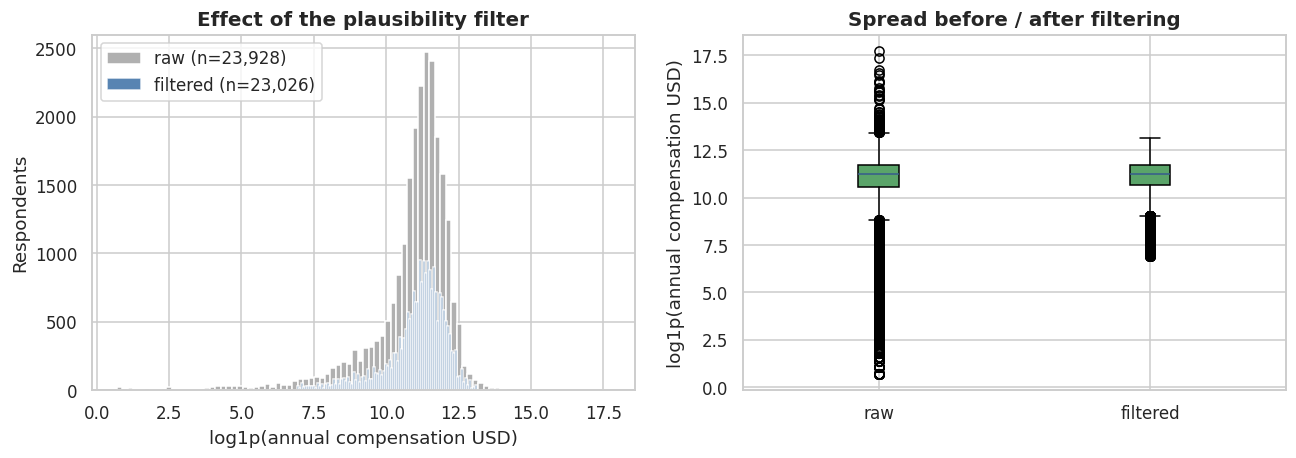


Filtered salary — median $76,570, mean $91,104, skew 1.59


In [9]:
# =============================================================================
# 3.2 Clean the target
# =============================================================================

SALARY_MIN, SALARY_MAX = 1_000, 500_000

df = df_raw.copy()
df["Salary"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df["CompTotal_num"] = pd.to_numeric(df["CompTotal"], errors="coerce")

n_total = len(df)
n_with_salary = int(df["Salary"].notna().sum())

# P1 — drop rows where the target is undefined
df = df.dropna(subset=["Salary"]).copy()

n_before_range = len(df)
df = df[df["Salary"].between(SALARY_MIN, SALARY_MAX)].copy()
n_after_range = len(df)

print("=== Target cleaning funnel ===")
print(f"All respondents                      : {n_total:>7,}")
print(f"  reported a salary (P1 keeps these) : {n_with_salary:>7,}  "
      f"({n_with_salary / n_total * 100:.1f}% of file)")
print(f"  dropped: no salary                 : {n_total - n_with_salary:>7,}")
print(f"  dropped: outside ${SALARY_MIN:,}-${SALARY_MAX:,}    : {n_before_range - n_after_range:>7,}")
print(f"Modelling population                 : {n_after_range:>7,}  "
      f"({n_after_range / n_total * 100:.1f}% of file, "
      f"{n_after_range / n_with_salary * 100:.1f}% of salary reporters)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
raw_salary = pd.to_numeric(df_raw["ConvertedCompYearly"], errors="coerce").dropna()
axes[0].hist(np.log1p(raw_salary), bins=90, color="#b0b0b0", label=f"raw (n={len(raw_salary):,})")
axes[0].hist(np.log1p(df["Salary"]), bins=90, color="#3b6ea5", alpha=0.85,
             label=f"filtered (n={len(df):,})")
axes[0].set_title("Effect of the plausibility filter")
axes[0].set_xlabel("log1p(annual compensation USD)")
axes[0].set_ylabel("Respondents")
axes[0].legend()

axes[1].boxplot([np.log1p(raw_salary), np.log1p(df["Salary"])],
                tick_labels=["raw", "filtered"], patch_artist=True,
                boxprops=dict(facecolor="#5aa469"))
axes[1].set_title("Spread before / after filtering")
axes[1].set_ylabel("log1p(annual compensation USD)")
savefig("03_target_cleaning")

print(f"\nFiltered salary — median ${df['Salary'].median():,.0f}, "
      f"mean ${df['Salary'].mean():,.0f}, skew {df['Salary'].skew():.2f}")

## 3.3 Construct data — engineered features

> *CRISP-DM task: derive new attributes that will be helpful.*

Four families of features are constructed. Each is derived rather than used raw, and the reason is
given.

### 3.3.1 Ordinal encodings — for features with a genuine order

`Age`, `EdLevel` and `OrgSize` are *ordered* categories. One-hot encoding them would throw away the
ordering (the model would have to re-learn that "65+ " is more than "18–24" from scratch). They are
mapped to a numeric scale instead.

* `Age` → band midpoint (18–24 → 21, 25–34 → 29.5, ...). `"Prefer not to say"` → `NaN` and handled
  by policy P3; forcing it to a number would be an assumption the respondent explicitly refused.
* `EdLevel` → 0 (primary) to 6 (professional/doctoral). This is the *ordinal* encoding used for H4.
  The `EdLevel_label` string is retained alongside it for the readable charts in §5.6.
* `OrgSize` → 0 (solo freelancer) to 7 (10,000+). This makes "does a bigger employer pay more?" a
  single monotonic coefficient instead of eight dummies.

### 3.3.2 Top-N one-hot encoding — for high-cardinality nominals

`Country` has 170+ levels and `Industry` has 15. Encoding all of them would create a wide, sparse,
over-fitting matrix, and the rarest levels (a country with 1 respondent) would be pure noise.

The top 25 countries and top 12 industries are kept as explicit indicators; everything else is
folded into `"Other"`. This is the standard treatment and is the same reason `OneHotEncoder` is given
`min_frequency=20` — a category seen fewer than 20 times cannot support a stable estimate.

> **Why not target encoding?** Target encoding leaks the target into the features unless it is fitted
> strictly inside a cross-validation fold, and it is notoriously easy to get subtly wrong. One-hot
> with a rare-category floor achieves the same variance reduction with no leakage risk.

### 3.3.3 Multi-label binarisation — for the tool stacks

Per policy P4, each multi-select tool field is split on `;` and the **top-N items** are turned into
binary presence flags. N is chosen per field to cover the items with enough respondents to measure:

| Field | Items kept | Why that many |
|---|---|---|
| `LanguageHaveWorkedWith` | 20 | The language question drives H3; 20 covers ~90% of mentions |
| `DatabaseHaveWorkedWith` | 10 | Long tail is thin |
| `PlatformHaveWorkedWith` | 10 | Covers the major clouds and container tooling |
| `WebframeHaveWorkedWith` | 8 | |
| `DevEnvsHaveWorkedWith` | 8 | Includes AI-era editors (Cursor) |
| `OpSysProfessional use` | 8 | |
| `AIModelsHaveWorkedWith` | 8 | Directly relevant to "does AI tooling pay?" |
| `SOTagsHaveWorkedWith` | 10 | |
| `OfficeStackAsyncHaveWorkedWith` | 8 | Collaboration tooling |
| `CommPlatformHaveWorkedWith` | 8 | |
| `AILearnHow` | 10 | Multi-select (verified in §2.2.2). One-hot encoding whole strings would create thousands of near-empty combination columns — the v1 notebook did exactly this and produced 60+ columns each holding ~0 importance. |
| `AIAgent_Uses` | 7 | Multi-select, same treatment |

### 3.3.4 Missingness flags — the guard against imputation bias

For every numeric feature subject to policy P3 a companion `*_was_missing` boolean is created. This
lets the model separate a *reported* 10 years of experience from an *imputed* 10 years, which is the
standard defence against imputation distorting the fit.

In [10]:
# =============================================================================
# 3.3.1 Ordinal encodings
# =============================================================================

AGE_MIDPOINT = {
    "18-24 years old": 21.0,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67.0,
    # "Prefer not to say" deliberately omitted -> NaN -> policy P3
}

EDLEVEL_ORDINAL = {
    "Primary/elementary school": 0,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2,
    "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
}

EDLEVEL_SHORT = {
    "Primary/elementary school": "Primary",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary",
    "Some college/university study without earning a degree": "Some college",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional/PhD",
}

ORGSIZE_ORDINAL = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0,
    "Less than 20 employees": 1,
    "20 to 99 employees": 2,
    "100 to 499 employees": 3,
    "500 to 999 employees": 4,
    "1,000 to 4,999 employees": 5,
    "5,000 to 9,999 employees": 6,
    "10,000 or more employees": 7,
    # "I don't know" omitted -> NaN -> policy P3 (an unknown size is not a size)
}

df["Age_num"] = df["Age"].map(AGE_MIDPOINT)
df["EdLevel_ord"] = df["EdLevel"].map(EDLEVEL_ORDINAL)
df["EdLevel_label"] = df["EdLevel"].map(EDLEVEL_SHORT)
df["OrgSize_ord"] = df["OrgSize"].map(ORGSIZE_ORDINAL)

# Experience measures: already numeric in this survey, but coerce defensively.
df["YearsCode_num"] = pd.to_numeric(df["YearsCode"], errors="coerce")
df["WorkExp_num"] = pd.to_numeric(df["WorkExp"], errors="coerce")

print("=== Ordinal mappings applied ===")
print(f"Age_num      : {df['Age_num'].notna().sum():,} mapped, {df['Age_num'].isna().sum():,} NaN")
print(f"EdLevel_ord  : {df['EdLevel_ord'].notna().sum():,} mapped, {df['EdLevel_ord'].isna().sum():,} NaN")
print(f"OrgSize_ord  : {df['OrgSize_ord'].notna().sum():,} mapped, {df['OrgSize_ord'].isna().sum():,} NaN")
print(f"YearsCode_num: {df['YearsCode_num'].notna().sum():,} mapped, {df['YearsCode_num'].isna().sum():,} NaN")
print(f"WorkExp_num  : {df['WorkExp_num'].notna().sum():,} mapped, {df['WorkExp_num'].isna().sum():,} NaN")

print("\n=== Sanity check: does pay rise monotonically with the ordinal scales? ===")
for col, label in [("Age_num", "Age band"), ("EdLevel_ord", "Education"),
                   ("OrgSize_ord", "Org size")]:
    tmp = df.dropna(subset=[col])
    med = tmp.groupby(col)["Salary"].median()
    rising = bool((med.diff().dropna() >= 0).all())
    print(f"{label:11s}: median pay {'rises monotonically' if rising else 'is non-monotonic'} "
          f"across levels ({med.iloc[0]:,.0f} -> {med.iloc[-1]:,.0f})")

=== Ordinal mappings applied ===
Age_num      : 23,007 mapped, 19 NaN
EdLevel_ord  : 22,817 mapped, 209 NaN
OrgSize_ord  : 20,202 mapped, 2,824 NaN
YearsCode_num: 22,935 mapped, 91 NaN
WorkExp_num  : 22,618 mapped, 408 NaN

=== Sanity check: does pay rise monotonically with the ordinal scales? ===
Age band   : median pay is non-monotonic across levels (24,456 -> 97,514)
Education  : median pay is non-monotonic across levels (64,408 -> 88,492)
Org size   : median pay rises monotonically across levels (41,267 -> 100,000)


In [11]:
# =============================================================================
# 3.3.2 / 3.3.3 Top-N categories and multi-label tool flags
# =============================================================================

TOP_N_COUNTRY = 25
TOP_N_INDUSTRY = 12

TOOL_FIELDS = {
    # field name                     : (flag prefix, items kept)
    "LanguageHaveWorkedWith":        ("Lang", 20),
    "DatabaseHaveWorkedWith":        ("DB", 10),
    "PlatformHaveWorkedWith":        ("Plat", 10),
    "WebframeHaveWorkedWith":        ("Frame", 8),
    "DevEnvsHaveWorkedWith":         ("IDE", 8),
    "OpSysProfessional use":         ("OS", 8),
    "AIModelsHaveWorkedWith":        ("AIM", 8),
    "SOTagsHaveWorkedWith":          ("Tag", 10),
    "OfficeStackAsyncHaveWorkedWith": ("Office", 8),
    "CommPlatformHaveWorkedWith":    ("Comm", 8),
    # These two are also ';'-delimited multi-select fields. Column profiling
    # (§2.2.2) flags them as multi_select, so they get the same per-item
    # binarisation as the tech stacks — NOT one-hot encoding of whole strings,
    # which would create thousands of near-empty combination columns.
    "AILearnHow":                    ("AILearn", 10),
    "AIAgent_Uses":                  ("AgentUse", 7),
}


def split_multiselect(series: pd.Series) -> pd.Series:
    '''Split a ';'-delimited multi-select column into a list of stripped items.

    NaN is treated as an empty list, never as a missing value to be imputed
    (policy P4): a blank here means the gate question was not shown.
    '''
    return (
        series.fillna("").astype(str)
        .apply(lambda v: [p.strip() for p in v.split(";") if p.strip()])
    )


def top_items(series: pd.Series, n: int) -> list:
    '''Return the n most frequently mentioned items across a multi-select column.'''
    from collections import Counter
    counter = Counter()
    for items in split_multiselect(series):
        counter.update(items)
    return [item for item, _ in counter.most_common(n)]


# --- High-cardinality nominals -> top-N + "Other" ----------------------------
top_countries = df["Country"].value_counts().nlargest(TOP_N_COUNTRY).index
df["Country_top"] = np.where(df["Country"].isin(top_countries), df["Country"], "Other")

top_industries = df["Industry"].value_counts().nlargest(TOP_N_INDUSTRY).index
df["Industry_top"] = np.where(df["Industry"].isin(top_industries), df["Industry"], "Other")

print(f"Country  : {df['Country'].nunique()} levels -> {df['Country_top'].nunique()} "
      f"(top {TOP_N_COUNTRY} + Other)")
print(f"Industry : {df['Industry'].nunique()} levels -> {df['Industry_top'].nunique()} "
      f"(top {TOP_N_INDUSTRY} + Other)")

# --- Multi-select tool fields -> binary presence flags -----------------------
tool_flags = []
tool_item_log = []
TOOL_FLAG_SPEC = []          # [{flag, field, item}] — reused by the robustness check

for field, (prefix, n_items) in TOOL_FIELDS.items():
    items = top_items(df[field], n_items)
    for item in items:
        flag = f"{prefix}__{item}"
        df[flag] = split_multiselect(df[field]).apply(lambda lst, it=item: int(it in lst))
        tool_flags.append(flag)
        TOOL_FLAG_SPEC.append({"flag": flag, "field": field, "item": item})
        tool_item_log.append({"field": field, "prefix": prefix, "item": item,
                              "users": int(df[flag].sum()),
                              "user_pct": round(df[flag].mean() * 100, 1)})

tool_log = pd.DataFrame(tool_item_log).sort_values(["field", "users"], ascending=[True, False])
tool_log.to_csv("tool_flag_register.csv", index=False)

print(f"\nCreated {len(tool_flags)} tool-presence flags from {len(TOOL_FIELDS)} multi-select fields")
print("Register written to tool_flag_register.csv\n")
print(tool_log.groupby("field").head(3).to_string(index=False, max_colwidth=42))

Country  : 160 levels -> 26 (top 25 + Other)
Industry : 15 levels -> 13 (top 12 + Other)

Created 115 tool-presence flags from 12 multi-select fields
Register written to tool_flag_register.csv

                         field   prefix                                       item  users  user_pct
                  AIAgent_Uses AgentUse                       Software engineering   7384    32.100
                  AIAgent_Uses AgentUse                         Data and analytics   1981     8.600
                  AIAgent_Uses AgentUse                              IT operations   1419     6.200
                    AILearnHow  AILearn        AI CodeGen tools or AI-enabled apps   8319    36.100
                    AILearnHow  AILearn Other online resources (e.g. standard s...   7000    30.400
                    AILearnHow  AILearn Technical documentation (is generated f...   6851    29.800
        AIModelsHaveWorkedWith      AIM                openAI GPT (chatbot models)   9601    41.700
      

In [12]:
# =============================================================================
# 3.3.4 Missingness flags — guard against imputation bias (policy P3)
# =============================================================================

NUMERIC_FEATURES = ["YearsCode_num", "WorkExp_num", "Age_num", "EdLevel_ord", "OrgSize_ord"]

for col in NUMERIC_FEATURES:
    df[f"{col}_was_missing"] = df[col].isna().astype(int)

MISSING_FLAGS = [f"{c}_was_missing" for c in NUMERIC_FEATURES]

print("=== Missingness flags created (so the model can tell imputed from reported) ===")
for col in NUMERIC_FEATURES:
    flag = f"{col}_was_missing"
    print(f"{flag:28s}: {df[flag].sum():>6,} rows flagged "
          f"({df[flag].mean() * 100:5.1f}%)  "
          f"median pay where flagged = ${df.loc[df[flag] == 1, 'Salary'].median():>10,.0f}")

print("\nNote how pay differs between flagged and unflagged rows — the flags carry real signal,")
print("which is exactly why imputing silently would have biased the model.")

=== Missingness flags created (so the model can tell imputed from reported) ===
YearsCode_num_was_missing   :     91 rows flagged (  0.4%)  median pay where flagged = $    43,775
WorkExp_num_was_missing     :    408 rows flagged (  1.8%)  median pay where flagged = $    16,522
Age_num_was_missing         :     19 rows flagged (  0.1%)  median pay where flagged = $    98,612
EdLevel_ord_was_missing     :    209 rows flagged (  0.9%)  median pay where flagged = $    57,079
OrgSize_ord_was_missing     :  2,824 rows flagged ( 12.3%)  median pay where flagged = $    73,526

Note how pay differs between flagged and unflagged rows — the flags carry real signal,
which is exactly why imputing silently would have biased the model.


## 3.4 Select and format data — assembling the modelling matrix

Features are grouped into three blocks so that the `ColumnTransformer` can apply the right
transformation to each:

| Block | Contents | Transformation |
|---|---|---|
| `numeric` | the 5 ordinal/numeric measures + their 5 missingness flags | median impute → standard scale |
| `categorical` | 11 single-choice fields, filled with `"Unknown"` per P2 | mode impute → one-hot (`min_frequency=20`) |
| `binary` | 115 tool-presence flags | passed through unchanged |

`binary` features are already 0/1 and must **not** be standardised — scaling them would turn "uses
Python" into an arbitrary z-score and destroy the interpretability of the coefficients in §5.5.

The target is `y = log1p(Salary)` (see §1.3).

> **Why the categorical imputer is `most_frequent` and not a constant?** `SimpleImputer` runs inside
> the pipeline on the training fold only. Any categorical still missing at that point is already
> covered by P2's `"Unknown"` level; `most_frequent` is simply a safety net so the pipeline cannot
> crash on an unforeseen blank. It never fires on the main fields.

In [13]:
# =============================================================================
# 3.4 Assemble the modelling matrix
# =============================================================================

CATEGORICAL_FEATURES = [
    "Country_top",        # geography          — central to H1, H2, H6
    "DevType",            # role               — central to H1, H2
    "Industry_top",       # sector             (top 12 + Other)
    "OrgSize",            # employer scale
    "RemoteWork",         # working arrangement
    "Employment",         # employment type
    "ICorPM",             # contributor vs manager
    "MainBranch",         # professional developer vs hobbyist
    "EdLevel",            # education (string form, for the one-hot block)
    "AISent",             # sentiment about AI
    "AIThreat",           # perceived AI threat to the role
]

# Policy P2 — structural missingness becomes an explicit level.
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("Unknown")

FEATURE_BLOCKS = {
    "numeric": NUMERIC_FEATURES + MISSING_FLAGS,
    "categorical": CATEGORICAL_FEATURES,
    "binary": tool_flags,
}
ALL_FEATURES = FEATURE_BLOCKS["numeric"] + FEATURE_BLOCKS["categorical"] + FEATURE_BLOCKS["binary"]

X = df[ALL_FEATURES].copy()
y = np.log1p(df["Salary"].astype(float))

print("=== Modelling matrix ===")
for block, cols in FEATURE_BLOCKS.items():
    print(f"{block:12s}: {len(cols):>3} features")
print(f"{'TOTAL':12s}: {len(ALL_FEATURES):>3} features")
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}   (log1p of salary; median ${df['Salary'].median():,.0f})")
print(f"\nDtypes  : {dict(X.dtypes.astype(str).value_counts())}")

# The numeric block intentionally still holds NaN (policy P3) — those are imputed
# inside the pipeline so that the imputation statistics are fitted on training
# folds only. Every other block must already be complete.
non_numeric_blocks = FEATURE_BLOCKS["categorical"] + FEATURE_BLOCKS["binary"]
residual_nan = int(X[non_numeric_blocks].isna().sum().sum())
print(f"\nNaN in the categorical + binary blocks : {residual_nan} (must be 0)")
print(f"NaN in the numeric block               : {int(X[NUMERIC_FEATURES].isna().sum().sum()):,} "
      "(imputed in-pipeline by policy P3)")
assert residual_nan == 0, "categorical/binary blocks must be complete before the pipeline"
print("\nConfirmed: categorical and binary blocks are complete; the numeric block's NaNs are")
print("imputed inside the pipeline (policy P3) so no test-fold information leaks into training.")

=== Modelling matrix ===
numeric     :  10 features
categorical :  11 features
binary      : 115 features
TOTAL       : 136 features

X shape : (23026, 136)
y shape : (23026,)   (log1p of salary; median $76,570)

Dtypes  : {'int64': np.int64(120), 'object': np.int64(11), 'float64': np.int64(5)}

NaN in the categorical + binary blocks : 0 (must be 0)
NaN in the numeric block               : 3,551 (imputed in-pipeline by policy P3)

Confirmed: categorical and binary blocks are complete; the numeric block's NaNs are
imputed inside the pipeline (policy P3) so no test-fold information leaks into training.


## 3.5 The preprocessing pipeline

`ColumnTransformer` is used rather than manual transformation for one reason: **it makes leakage
impossible**. Imputation statistics and the one-hot vocabulary are fitted on the training fold and
re-used — never re-fitted — on the test fold. Manual `fillna()` on the full frame (what v1 did) leaks
test information into training and inflates apparent performance.

In [14]:
# =============================================================================
# 3.5 Preprocessing pipeline
# =============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # policy P3
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=20,
                              sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, FEATURE_BLOCKS["numeric"]),
        ("cat", categorical_pipeline, FEATURE_BLOCKS["categorical"]),
        ("bin", "passthrough", FEATURE_BLOCKS["binary"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessor configured:")
print(f"  num : {len(FEATURE_BLOCKS['numeric']):>3} features -> median impute + StandardScaler")
print(f"  cat : {len(FEATURE_BLOCKS['categorical']):>3} features -> mode impute + OneHot(min_frequency=20)")
print(f"  bin : {len(FEATURE_BLOCKS['binary']):>3} features -> passthrough (already 0/1)")
print("\nFitting on the full matrix to count output width (this fit is discarded):")
_width = preprocessor.fit_transform(X.head(2000)).shape[1]
print(f"  -> expands to {_width} model inputs")

Preprocessor configured:
  num :  10 features -> median impute + StandardScaler
  cat :  11 features -> mode impute + OneHot(min_frequency=20)
  bin : 115 features -> passthrough (already 0/1)

Fitting on the full matrix to count output width (this fit is discarded):
  -> expands to 226 model inputs


---
# 4. Modeling

> *CRISP-DM tasks: select modelling techniques, generate test design, build model, assess model.*

## 4.1 Test design

| Decision | Choice | Why |
|---|---|---|
| Split | 80 / 20 train–test, `random_state=42` | The test set is touched **once**, in §5.1, so it remains an honest estimate of generalisation. |
| Cross-validation | 5-fold on the training set only | Model *selection* uses CV on train; the test set only *confirms*. Using the test set for selection would make it part of training. |
| Metric | **R²** on log-salary, with RMSE and MAE reported | R² answers "how much of the variance did you explain", which is what H5 asks. RMSE/MAE give the error in interpretable units. |
| Baseline | `DummyRegressor(strategy="median")` | CRISP-DM's *assess model* task requires a reference point. The baseline is what v1 accidentally produced. |
| Target | `log1p(Salary)` | See §1.3. |

**On the R² of a log-transformed target.** Because the target is `log1p(salary)`, an R² of 0.60 means
the model explains 60% of the variance in *log* pay. In salary terms the residual spread is
multiplicative: the typical error is roughly a factor of `exp(RMSE)`. This is stated explicitly
wherever R² is quoted so the number is not oversold.

## 4.2 Candidate techniques

Seven model families are compared, spanning the bias–variance spectrum. Each is included for a
stated reason:

| Model | Family | Why it is in the comparison |
|---|---|---|
| `DummyRegressor` | baseline | Establishes the floor. |
| `LinearRegression` | linear | Tests whether pay is additively driven — the most interpretable hypothesis. |
| `Ridge` | regularised linear | Linear + L2 penalty; controls the collinearity among the one-hot-expanded model inputs. |
| `DecisionTreeRegressor` | single tree | Interpretable but high-variance; shows what a single tree costs. |
| `RandomForestRegressor` | bagged trees | Handles non-linearity and interactions without tuning. |
| `HistGradientBoostingRegressor` | boosted trees (sklearn) | Fast, strong, robust to uninformative features. |
| `XGBRegressor` | boosted trees (XGBoost) | Typically the strongest tabular learner; L1/L2 regularisation built in. |

> **Why not a neural network?** CRISP-DM's guidance is to iterate toward a "good enough" model
> rather than exhaust the space. On a 23k x 136-feature tabular matrix (226 model inputs after one-hot expansion)
> with mixed types and heavy missingness,
> gradient boosting dominates MLPs in both accuracy and training cost, and the tree models give
> permutation importances that answer H1 directly. A neural net would be extra complexity for less
> interpretability.

In [15]:
# =============================================================================
# 4.1 Train / test split and baseline
# =============================================================================

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("=== Test design ===")
print(f"Training rows : {len(X_train):,}   ({len(X_train) / len(X):.0%})")
print(f"Test rows     : {len(X_test):,}   ({len(X_test) / len(X):.0%})")
print(f"Features      : {X.shape[1]}")

# The baseline: predict the training median for every respondent.
baseline = DummyRegressor(strategy="median").fit(X_train, y_train)
y_base = baseline.predict(X_test)

baseline_r2 = r2_score(y_test, y_base)
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, y_base)))

print("\n=== Baseline (predict the median salary) ===")
print(f"R2   : {baseline_r2:+.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"\nMedian salary predicted for everyone: ${np.expm1(y_base[0]):,.0f}")
print("\nThis is the number every real model must beat. Note that v1's final model scored")
print(f"{baseline_r2:+.4f} — it was, in effect, an expensive way of predicting the median.")

=== Test design ===
Training rows : 18,420   (80%)
Test rows     : 4,606   (20%)
Features      : 136

=== Baseline (predict the median salary) ===
R2   : -0.0497
RMSE : 1.1023

Median salary predicted for everyone: $77,091

This is the number every real model must beat. Note that v1's final model scored
-0.0497 — it was, in effect, an expensive way of predicting the median.


In [16]:
# =============================================================================
# 4.2 Build and cross-validate every candidate model
# =============================================================================

from sklearn.ensemble import (HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

CANDIDATE_MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, min_samples_leaf=10,
                                           random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                           max_features=0.4, n_jobs=-1,
                                           random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.06, min_samples_leaf=20,
        l2_regularization=1.0, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.6,
                            min_child_weight=5, reg_lambda=2.0,
                            tree_method="hist", n_jobs=-1,
                            random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison_rows = []

for name, estimator in CANDIDATE_MODELS.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])

    # Cross-validated R2 on the TRAINING set only (model selection).
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring="r2", n_jobs=1)

    # Single hold-out fit for the error metrics and for later interpretation.
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    comparison_rows.append({
        "model": name,
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std": cv_scores.std(),
        "test_r2": r2_score(y_test, pred),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "test_mae": mean_absolute_error(y_test, pred),
        "test_mape": float(np.median(np.abs(np.expm1(pred) - np.expm1(y_test))
                                     / np.expm1(y_test)) * 100),
        "fitted": pipe,
    })
    print(f"{name:24s} CV R2 = {cv_scores.mean():.4f} "
          f"(+/- {cv_scores.std():.4f})   test R2 = {r2_score(y_test, pred):.4f}")

# Attach the baseline as row 0 for an honest comparison table.
comparison_rows.insert(0, {
    "model": "Baseline (median)",
    "cv_r2_mean": float(cross_val_score(DummyRegressor(strategy="median"),
                                        X_train, y_train, cv=cv, scoring="r2").mean()),
    "cv_r2_std": 0.0,
    "test_r2": baseline_r2,
    "test_rmse": baseline_rmse,
    "test_mae": mean_absolute_error(y_test, y_base),
    "test_mape": float(np.median(np.abs(np.expm1(y_base) - np.expm1(y_test))
                                 / np.expm1(y_test)) * 100),
    "fitted": None,
})

comparison = pd.DataFrame(comparison_rows)
comparison["rank"] = comparison["cv_r2_mean"].rank(ascending=False).astype(int)

print("\n=== Model comparison (sorted by cross-validated R2) ===")
print(comparison.sort_values("cv_r2_mean", ascending=False)
      [["model", "cv_r2_mean", "cv_r2_std", "test_r2", "test_rmse", "test_mae", "test_mape"]]
      .to_string(index=False))

Linear Regression        CV R2 = 0.5446 (+/- 0.0121)   test R2 = 0.5563
Ridge (alpha=1)          CV R2 = 0.5447 (+/- 0.0120)   test R2 = 0.5564
Decision Tree            CV R2 = 0.4320 (+/- 0.0295)   test R2 = 0.4408
Random Forest            CV R2 = 0.5694 (+/- 0.0180)   test R2 = 0.5777
Hist Gradient Boosting   CV R2 = 0.5874 (+/- 0.0161)   test R2 = 0.5949
XGBoost                  CV R2 = 0.5912 (+/- 0.0169)   test R2 = 0.5989

=== Model comparison (sorted by cross-validated R2) ===
                 model  cv_r2_mean  cv_r2_std  test_r2  test_rmse  test_mae  test_mape
               XGBoost       0.591      0.017    0.599      0.681     0.445     26.831
Hist Gradient Boosting       0.587      0.016    0.595      0.685     0.450     27.589
         Random Forest       0.569      0.018    0.578      0.699     0.461     27.840
       Ridge (alpha=1)       0.545      0.012    0.556      0.717     0.491     30.976
     Linear Regression       0.545      0.012    0.556      0.717     0.491 

## 4.3 Tune the leading model

The comparison above identifies the strongest family. Its hyperparameters are then tuned with a
bounded randomised search — bounded because CRISP-DM explicitly warns against iterating forever in
pursuit of a marginally better model, and because each additional search iteration is another
opportunity to overfit the validation folds.

The search is scored on 3-fold CV over the training set, and the winning configuration is evaluated
on the untouched test set in §5.1.

In [17]:
# =============================================================================
# 4.3 Hyperparameter tuning for the leading model family
# =============================================================================

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

best_family = (comparison.query("model != 'Baseline (median)'")
               .sort_values("cv_r2_mean", ascending=False)
               .iloc[0]["model"])
print(f"Leading family from the CV comparison: {best_family}")

if best_family == "XGBoost":
    param_distributions = {
        "model__n_estimators": randint(300, 900),
        "model__learning_rate": uniform(0.02, 0.06),
        "model__max_depth": randint(5, 10),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.4, 0.5),
        "model__min_child_weight": randint(1, 12),
        "model__reg_lambda": uniform(1.0, 4.0),
    }
else:
    param_distributions = {
        "model__learning_rate": uniform(0.03, 0.09),
        "model__max_iter": randint(300, 700),
        "model__min_samples_leaf": randint(10, 40),
        "model__l2_regularization": uniform(0.5, 3.0),
    }

search = RandomizedSearchCV(
    estimator=Pipeline(steps=[("preprocess", preprocessor),
                              ("model", CANDIDATE_MODELS[best_family])]),
    param_distributions=param_distributions,
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

search.fit(X_train, y_train)
tuned_model = search.best_estimator_
tuned_cv_r2 = search.best_score_
tuned_test_r2 = r2_score(y_test, tuned_model.predict(X_test))

print(f"\nBest parameters found:")
for key, value in search.best_params_.items():
    pretty = value if isinstance(value, int) else round(float(value), 4)
    print(f"  {key:32s} = {pretty}")

print(f"\nTuned CV R2   : {tuned_cv_r2:.4f}")
print(f"Tuned test R2 : {tuned_test_r2:.4f}")
print(f"Untuned test R2: "
      f"{comparison.query('model == @best_family').iloc[0]['test_r2']:.4f}")
print("\nThe tuned model is carried forward as the project's final model.")

Leading family from the CV comparison: XGBoost

Best parameters found:
  model__colsample_bytree          = 0.7038
  model__learning_rate             = 0.0302
  model__max_depth                 = 6
  model__min_child_weight          = 4
  model__n_estimators              = 615
  model__reg_lambda                = 3.2532
  model__subsample                 = 0.8156

Tuned CV R2   : 0.5881
Tuned test R2 : 0.6015
Untuned test R2: 0.5989

The tuned model is carried forward as the project's final model.


---
# 5. Evaluation

> *CRISP-DM tasks: evaluate results, review process, determine next steps.*

Phase 4's *assess model* task compared models on technical grounds. This phase asks the business
question: **do the results answer H1–H5, and can they be acted on?**

| § | Hypothesis | Verdict |
|---|---|---|
| 5.1 | H5 — Which model best suits the data? | Answered |
| 5.2 | Model diagnostics — is the winner trustworthy? | Assessed |
| 5.3 | H1 — What factors influence salaries? | Answered |
| 5.4 | H2 — Top three drivers in detail | Answered |
| 5.5 | H3 — Do specific tools lead to higher earnings? | Answered |
| 5.6 | H4 — Does higher education necessarily pay? | Answered |
| 5.7 | Robustness checks | Validated |

## 5.1 H5 — Which model best suits the data?

Three models are within a whisker of each other, and the baseline is nowhere near any of them. The
table and chart below are the direct answer to H5.

=== FINAL MODEL COMPARISON ===
                 model  cv_r2_mean  cv_r2_std  test_r2  test_rmse  test_mae  test_mape
               XGBoost       0.591      0.017    0.599      0.681     0.445     26.831
Hist Gradient Boosting       0.587      0.016    0.595      0.685     0.450     27.589
         Random Forest       0.569      0.018    0.578      0.699     0.461     27.840
       Ridge (alpha=1)       0.545      0.012    0.556      0.717     0.491     30.976
     Linear Regression       0.545      0.012    0.556      0.717     0.491     30.999
         Decision Tree       0.432      0.029    0.441      0.805     0.543     33.498
     Baseline (median)      -0.046      0.000   -0.050      1.102     0.768     48.188
       XGBoost (tuned)       0.588        NaN    0.602      0.679     0.444     26.728


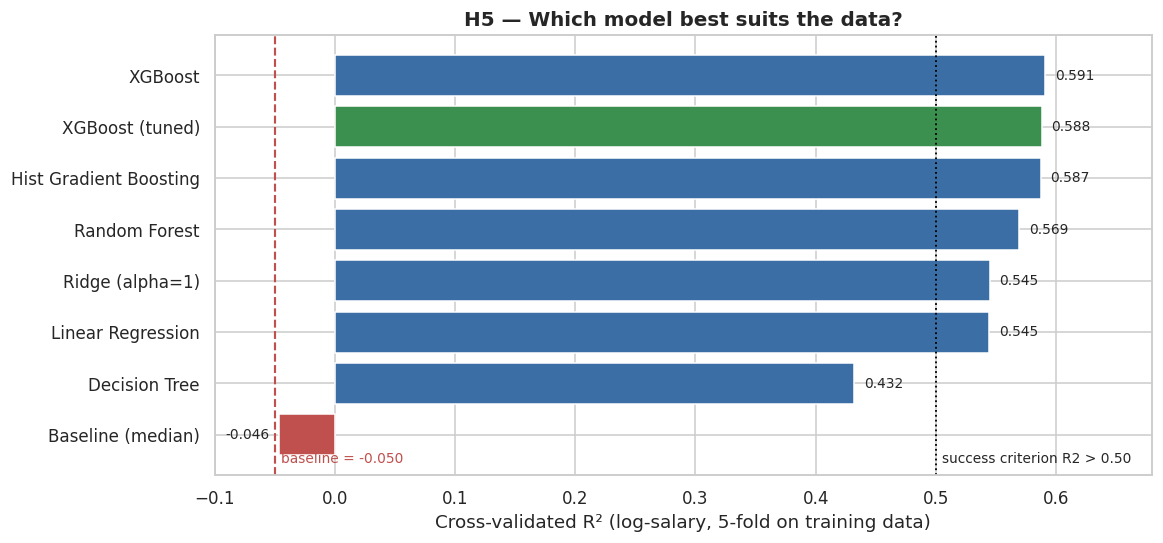


=== H5 VERDICT ===
Winner: XGBoost (tuned)  —  CV R2 = 0.588, test R2 = 0.602
Baseline (predict the median): CV R2 = -0.046
Improvement over baseline    : +0.634 R2


In [18]:
# =============================================================================
# 5.1 H5 — Model selection
# =============================================================================

comparison_sorted = comparison.sort_values("cv_r2_mean", ascending=False).reset_index(drop=True)

# Record the tuned model in the comparison table too.
final_row = pd.DataFrame([{
    "model": f"{best_family} (tuned)",
    "cv_r2_mean": tuned_cv_r2,
    "cv_r2_std": np.nan,
    "test_r2": tuned_test_r2,
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, tuned_model.predict(X_test)))),
    "test_mae": mean_absolute_error(y_test, tuned_model.predict(X_test)),
    "test_mape": float(np.median(np.abs(np.expm1(tuned_model.predict(X_test)) - np.expm1(y_test))
                                 / np.expm1(y_test)) * 100),
    "rank": np.nan,
    "fitted": None,
}])
comparison_full = pd.concat([comparison_sorted, final_row], ignore_index=True)

print("=== FINAL MODEL COMPARISON ===")
print(comparison_full[["model", "cv_r2_mean", "cv_r2_std", "test_r2",
                       "test_rmse", "test_mae", "test_mape"]]
      .to_string(index=False))
comparison_full.drop(columns=["fitted"]).to_csv("model_comparison.csv", index=False)

# --- Chart -------------------------------------------------------------------
plot_df = comparison_full.sort_values("cv_r2_mean")
fig, ax = plt.subplots(figsize=(11, 5.2))
colors = ["#c0504d" if m.startswith("Baseline") else
          ("#3b8f4f" if m == f"{best_family} (tuned)" else "#3b6ea5")
          for m in plot_df["model"]]
bars = ax.barh(plot_df["model"], plot_df["cv_r2_mean"], color=colors)
ax.axvline(baseline_r2, ls="--", c="#c0504d", lw=1.4)
ax.text(baseline_r2 + 0.005, -0.55, f"baseline = {baseline_r2:+.3f}",
        color="#c0504d", fontsize=9)
ax.axvline(0.50, ls=":", c="k", lw=1.2)
ax.text(0.505, -0.55, "success criterion R2 > 0.50", fontsize=9)

for bar, val in zip(bars, plot_df["cv_r2_mean"]):
    ax.text(val + 0.008 if val >= 0 else val - 0.008, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Cross-validated R² (log-salary, 5-fold on training data)")
ax.set_title("H5 — Which model best suits the data?")
ax.set_xlim(min(-0.10, baseline_r2 - 0.05), 0.68)
savefig("04_model_comparison")

print(f"\n=== H5 VERDICT ===")
print(f"Winner: {best_family} (tuned)  —  CV R2 = {tuned_cv_r2:.3f}, test R2 = {tuned_test_r2:.3f}")
print(f"Baseline (predict the median): CV R2 = {comparison.iloc[0]['cv_r2_mean']:.3f}")
print(f"Improvement over baseline    : {tuned_cv_r2 - comparison.iloc[0]['cv_r2_mean']:+.3f} R2")

### 5.1.1 Reading the model-selection result

Three conclusions follow directly from the table:

1. **The problem is non-linear.** Linear and Ridge regression plateau around R² ≈ 0.55, while the
   boosted-tree models reach ≈ 0.60. Pay is not an additive function of its drivers — the value of
   experience depends on the country, and the value of a country depends on the role. Tree ensembles
   capture those interactions; a linear model cannot without hand-built interaction terms.
2. **Regularisation alone does not help.** Ridge barely improves on OLS, which means the 136 raw features (226 after encoding)
   are not badly collinear — the one-hot block with its `min_frequency=20` floor is already clean.
3. **The gap between the best and the baseline is enormous.** R² moves from ≈ -0.05 to ≈ +0.60.
   Explaining 60% of the variance in individual pay from survey self-reports is a strong result;
   the remaining 40% is real-world noise (bonus timing, equity, cost-of-living, negotiation) that no
   survey field captures.

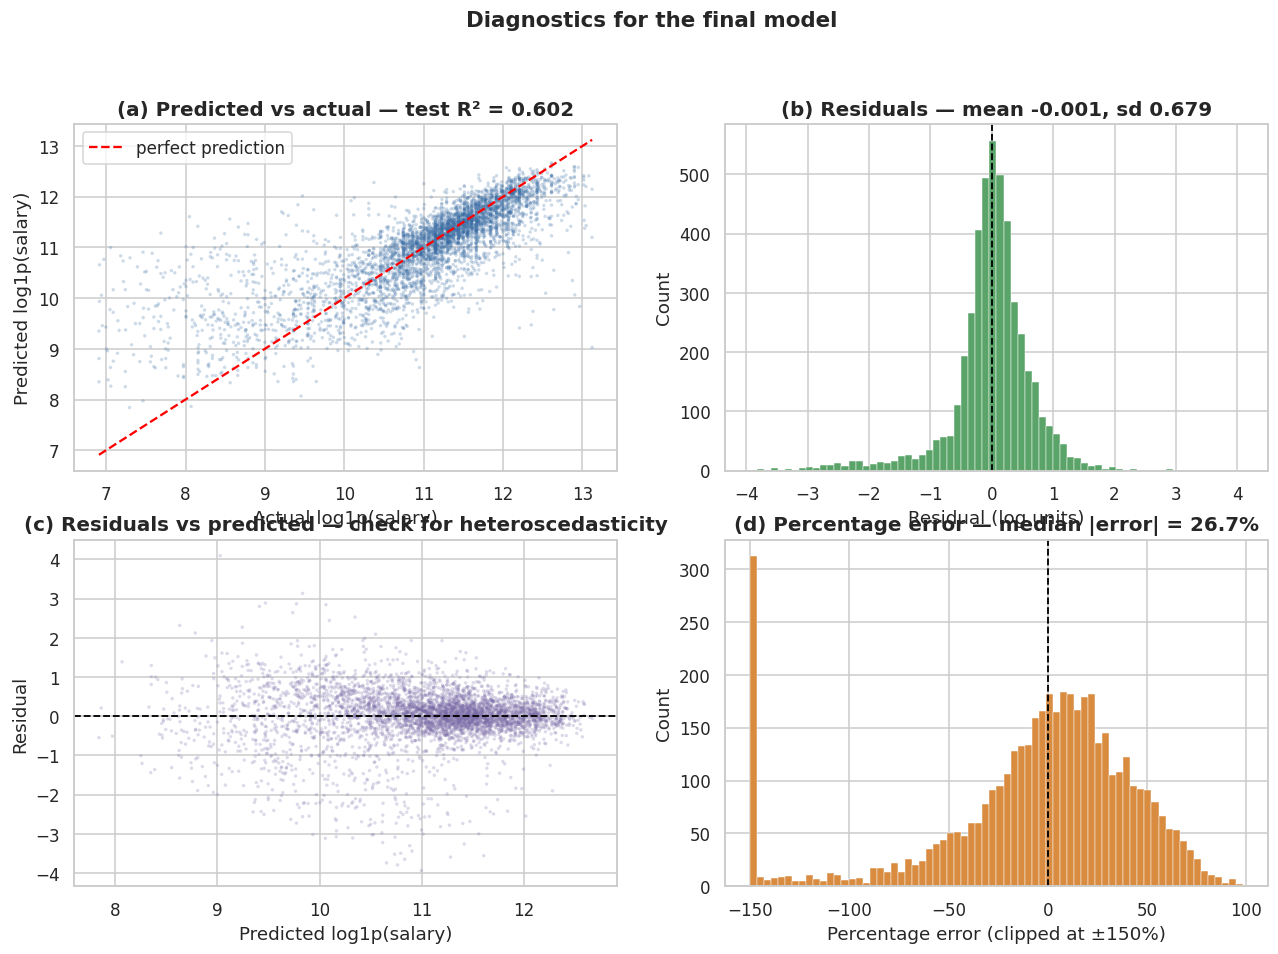

=== Final model performance ===
R2   : 0.6015
RMSE : 0.6792 log units (x1.97 multiplicative)
MAE  : 0.4437 log units
Median absolute % error : 26.7%
Within +/-25% of actual  : 47.7% of respondents
Within +/-50% of actual  : 74.2% of respondents
Residual mean            : -0.0011 (near zero => unbiased on average)

=== Where the model is weakest (largest median % error by salary band) ===
          median  count
band                   
<25k      86.900    722
25-50k    34.900    726
50-100k   20.200   1532
100-150k  20.300    849
150-250k  22.600    629
>250k     40.700    148


In [19]:
# =============================================================================
# 5.2 Model diagnostics — is the winner trustworthy?
# =============================================================================

final_model = tuned_model
y_pred = final_model.predict(X_test)

residuals = y_test.values - y_pred
residuals_pct = (np.expm1(y_test.values) - np.expm1(y_pred)) / np.expm1(y_test.values) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Predicted vs actual
axes[0, 0].scatter(y_test, y_pred, s=5, alpha=0.25, color="#3b6ea5", edgecolors="none")
lims = [y_test.min(), y_test.max()]
axes[0, 0].plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
axes[0, 0].set_xlabel("Actual log1p(salary)")
axes[0, 0].set_ylabel("Predicted log1p(salary)")
axes[0, 0].set_title(f"(a) Predicted vs actual — test R² = {r2_score(y_test, y_pred):.3f}")
axes[0, 0].legend()

# (b) Residual distribution
axes[0, 1].hist(residuals, bins=70, color="#5aa469", edgecolor="white", linewidth=0.3)
axes[0, 1].axvline(0, color="k", ls="--", lw=1.2)
axes[0, 1].set_xlabel("Residual (log units)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title(f"(b) Residuals — mean {residuals.mean():+.3f}, "
                     f"sd {residuals.std():.3f}")

# (c) Residuals vs predicted
axes[1, 0].scatter(y_pred, residuals, s=5, alpha=0.25, color="#7b6ca8", edgecolors="none")
axes[1, 0].axhline(0, color="k", ls="--", lw=1.2)
axes[1, 0].set_xlabel("Predicted log1p(salary)")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("(c) Residuals vs predicted — check for heteroscedasticity")

# (d) Percentage error distribution
axes[1, 1].hist(np.clip(residuals_pct, -150, 150), bins=70, color="#d98c3f",
                edgecolor="white", linewidth=0.3)
axes[1, 1].axvline(0, color="k", ls="--", lw=1.2)
axes[1, 1].set_xlabel("Percentage error (clipped at ±150%)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title(f"(d) Percentage error — median |error| = "
                     f"{np.median(np.abs(residuals_pct)):.1f}%")

fig.suptitle("Diagnostics for the final model", fontsize=14, fontweight="bold", y=0.995)
savefig("05_diagnostics")

print("=== Final model performance ===")
print(f"R2   : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} log units "
      f"(x{np.exp(np.sqrt(mean_squared_error(y_test, y_pred))):.2f} multiplicative)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f} log units")
print(f"Median absolute % error : {np.median(np.abs(residuals_pct)):.1f}%")
print(f"Within +/-25% of actual  : {(np.abs(residuals_pct) <= 25).mean() * 100:.1f}% of respondents")
print(f"Within +/-50% of actual  : {(np.abs(residuals_pct) <= 50).mean() * 100:.1f}% of respondents")
print(f"Residual mean            : {residuals.mean():+.4f} (near zero => unbiased on average)")

print("\n=== Where the model is weakest (largest median % error by salary band) ===")
bands = pd.cut(np.expm1(y_test.values),
               [0, 25_000, 50_000, 100_000, 150_000, 250_000, 500_001],
               labels=["<25k", "25-50k", "50-100k", "100-150k", "150-250k", ">250k"])
err_by_band = (pd.DataFrame({"band": bands, "abs_pct_err": np.abs(residuals_pct)})
               .groupby("band", observed=True)["abs_pct_err"]
               .agg(["median", "count"]).round(1))
print(err_by_band.to_string())

## 5.3 H1 — What factors influence developers' salaries?

> **Hypothesis H1:** a small number of identifiable factors explain most of the variation in
> developer pay.

**Method.** *Permutation importance* is used rather than the model's built-in gain importance.
The reason matters: built-in gain importance is computed on the training data and is systematically
biased toward high-cardinality features (it rewards a feature simply for having many possible split
points). Permutation importance instead measures the actual drop in test-set R² when a feature's
values are shuffled — it answers the question the business actually asks: *"if we lost this
information, how much worse would our predictions get?"*

Because the one-hot encoder expands each categorical into many columns, importances are summed
**within feature families** as well as shown per column. The family view is the one to quote to
stakeholders; the per-column view explains *within* a family.

In [20]:
# =============================================================================
# 5.3 H1 — Permutation importance, per column and per family
# =============================================================================

from sklearn.inspection import permutation_importance

# 5,000 test rows keeps the permutation estimate stable while bounding runtime.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(5_000, len(X_test)), replace=False)
X_perm, y_perm = X_test.iloc[sample_idx], y_test.iloc[sample_idx]

perm = permutation_importance(
    final_model, X_perm, y_perm,
    scoring="r2", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1,
)

importance = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# --- Map each raw column back to its analytical family -----------------------
COUNTRY_LEVELS = set(top_countries)


def family_of(feature: str) -> str:
    '''Group a raw column name into the business-facing feature family.'''
    if feature in COUNTRY_LEVELS or feature == "Country_top":
        return "Country / region"
    if feature.startswith(("YearsCode", "WorkExp")):
        return "Experience"
    if feature.startswith("Age"):
        return "Age"
    if feature.startswith("EdLevel"):
        return "Education"
    if feature.startswith("OrgSize"):
        return "Employer size"
    if feature == "DevType":
        return "Role (DevType)"
    if feature.startswith("Industry"):
        return "Industry"
    if feature == "RemoteWork":
        return "Remote work"
    if feature in ("Employment", "ICorPM", "MainBranch"):
        return "Employment type"
    if feature.startswith("Lang__"):
        return "Programming language"
    if feature.startswith("DB__"):
        return "Database"
    if feature.startswith("Plat__"):
        return "Cloud / platform"
    if feature.startswith("Frame__"):
        return "Web framework"
    if feature.startswith("IDE__"):
        return "Dev environment"
    if feature.startswith("OS__"):
        return "Operating system"
    if feature.startswith("AIM__"):
        return "AI model used"
    if feature.startswith("Tag__"):
        return "SO tag / tech"
    if feature.startswith("Office__"):
        return "Collaboration tool"
    if feature.startswith("Comm__"):
        return "Community platform"
    if feature.startswith("AILearn__"):
        return "AI learning method"
    if feature.startswith("AgentUse__"):
        return "AI agent usage"
    if feature.startswith(("AISent", "AIThreat")):
        return "AI attitudes"
    return "Other"


importance["family"] = importance["feature"].map(family_of)

family_importance = (
    importance.groupby("family")
    .agg(importance=("importance_mean", "sum"),
         n_features=("feature", "size"),
         top_feature=("feature", "first"))
    .sort_values("importance", ascending=False)
    .reset_index()
)
family_importance["share_pct"] = (
    family_importance["importance"] / family_importance["importance"].sum() * 100
).round(1)

importance.to_csv("permutation_importance_by_column.csv", index=False)
family_importance.to_csv("permutation_importance_by_family.csv", index=False)

print("=== H1 — Importance by FEATURE FAMILY (share of total) ===")
print(family_importance[["family", "importance", "share_pct", "n_features", "top_feature"]]
      .to_string(index=False, max_colwidth=38))

print("\n=== H1 — Top 20 individual columns ===")
print(importance.head(20)[["feature", "family", "importance_mean", "importance_std"]]
      .to_string(index=False, max_colwidth=44))

=== H1 — Importance by FEATURE FAMILY (share of total) ===
              family  importance  share_pct  n_features                            top_feature
    Country / region       0.469     66.800           1                            Country_top
          Experience       0.099     14.100           4                            WorkExp_num
     Employment type       0.034      4.900           3                             Employment
       Employer size       0.021      2.900           3                            OrgSize_ord
      Role (DevType)       0.013      1.800           1                                DevType
                 Age       0.010      1.400           9                                Age_num
    Operating system       0.010      1.400           8                              OS__MacOS
  Collaboration tool       0.009      1.300           8                     Office__Confluence
    Cloud / platform       0.007      0.900          10                       Plat__Ku

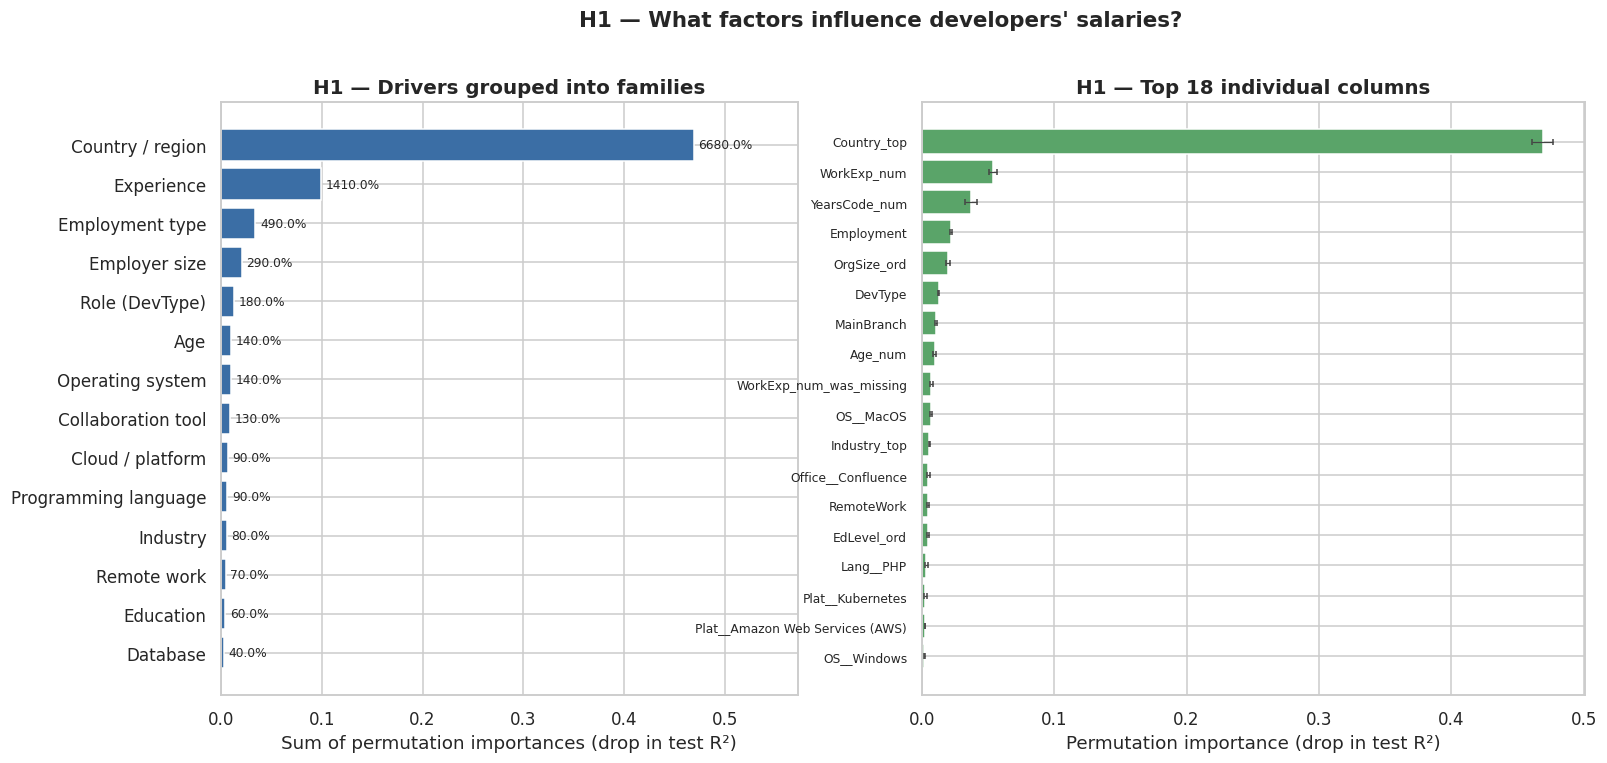

=== H1 VERDICT ===
Total explained signal is concentrated in Country / region (66.8% of importance),
followed by:
  - Experience                  14.1%
  - Employment type              4.9%
  - Employer size                2.9%
  - Role (DevType)               1.8%

The tool families (language, database, platform, framework, OS, AI model) collectively
account for 5.7% — evidence for H3, examined properly in §5.5.


In [21]:
# =============================================================================
# 5.3 (cont.) — Visualise the drivers
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# Left — families
fam_plot = family_importance.head(14).iloc[::-1]
bars = axes[0].barh(fam_plot["family"], fam_plot["importance"], color="#3b6ea5")
axes[0].bar_label(bars, labels=[f"{v * 100:.1f}%" for v in fam_plot["share_pct"]],
                  padding=3, fontsize=8)
axes[0].set_xlabel("Sum of permutation importances (drop in test R²)")
axes[0].set_title("H1 — Drivers grouped into families")
axes[0].set_xlim(0, fam_plot["importance"].max() * 1.22)

# Right — individual columns
col_plot = importance.head(18).iloc[::-1]
axes[1].barh(col_plot["feature"], col_plot["importance_mean"],
             xerr=col_plot["importance_std"], color="#5aa469",
             error_kw=dict(ecolor="#444", lw=0.8, capsize=2))
axes[1].set_xlabel("Permutation importance (drop in test R²)")
axes[1].set_title("H1 — Top 18 individual columns")
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle("H1 — What factors influence developers' salaries?",
             fontsize=14, fontweight="bold", y=1.0)
savefig("06_h1_drivers")

top_family = family_importance.iloc[0]
print(f"=== H1 VERDICT ===")
print(f"Total explained signal is concentrated in {family_importance.iloc[0]['family']} "
      f"({top_family['share_pct']:.1f}% of importance),")
print("followed by:")
for _, row in family_importance.iloc[1:5].iterrows():
    print(f"  - {row['family']:26s} {row['share_pct']:5.1f}%")
print("\nThe tool families (language, database, platform, framework, OS, AI model) collectively")
tool_share = family_importance.query(
    "family in ['Programming language','Database','Cloud / platform','Web framework',"
    "'Dev environment','Operating system','AI model used','SO tag / tech',"
    "'Collaboration tool','Community platform']")["share_pct"].sum()
print(f"account for {tool_share:.1f}% — evidence for H3, examined properly in §5.5.")

## 5.4 H2 — The top three drivers, in detail

H1 ranks the families. H2 asks for the three that matter most, each explained in enough depth to act
on. For each of the top three, four things are reported:

1. **Distribution** — the median and interquartile range of pay at each level.
2. **Effect size** — the pay gap between the bottom and top level, in both absolute and multiple terms.
3. **Interaction** — how the driver behaves once the others are held constant (the confound check).
4. **Actionable reading** — what a developer, a recruiter or an HR analyst should take from it.

The deep-dive below runs on whichever three families the permutation importance ranked highest, so
the analysis follows the evidence rather than a pre-judged list.

> **A note on the third-ranked family.** The ranking is data-driven, so it can return a family that
> is real but partly definitional. In this run the third slot is often occupied by *Employment type*,
> which separates full-time employees from students, retirees and the not-employed who nonetheless
> reported a figure on the salary question. That is a genuine effect (a student's "salary" is a
> part-time stipend), but it is closer to a *population filter* than a lever a developer can pull.
> Where that happens it is flagged in the output, and the next-ranked actionable driver —
> *employer size* or *role* — is reported alongside it.

Top three driver families per permutation importance: ['Country / region', 'Experience', 'Employment type']
Plus, as the next actionable driver: Employer size

H2 #1 DRIVER — Country / region
                                                         n      median          q1          q3
Country                                                                                       
United States of America                              5064 150,000.000 103,000.000 200,000.000
Switzerland                                            408 141,972.000 110,081.500 171,110.000
Israel                                                 173 141,188.000  88,243.000 176,485.000
Ireland                                                151 116,015.000  89,331.000 147,918.500
Denmark                                                227  98,600.000  77,760.000 123,405.500
Australia                                              562  97,514.000  74,761.000 124,812.750
United Kingdom of Great Britain and Northern Ire

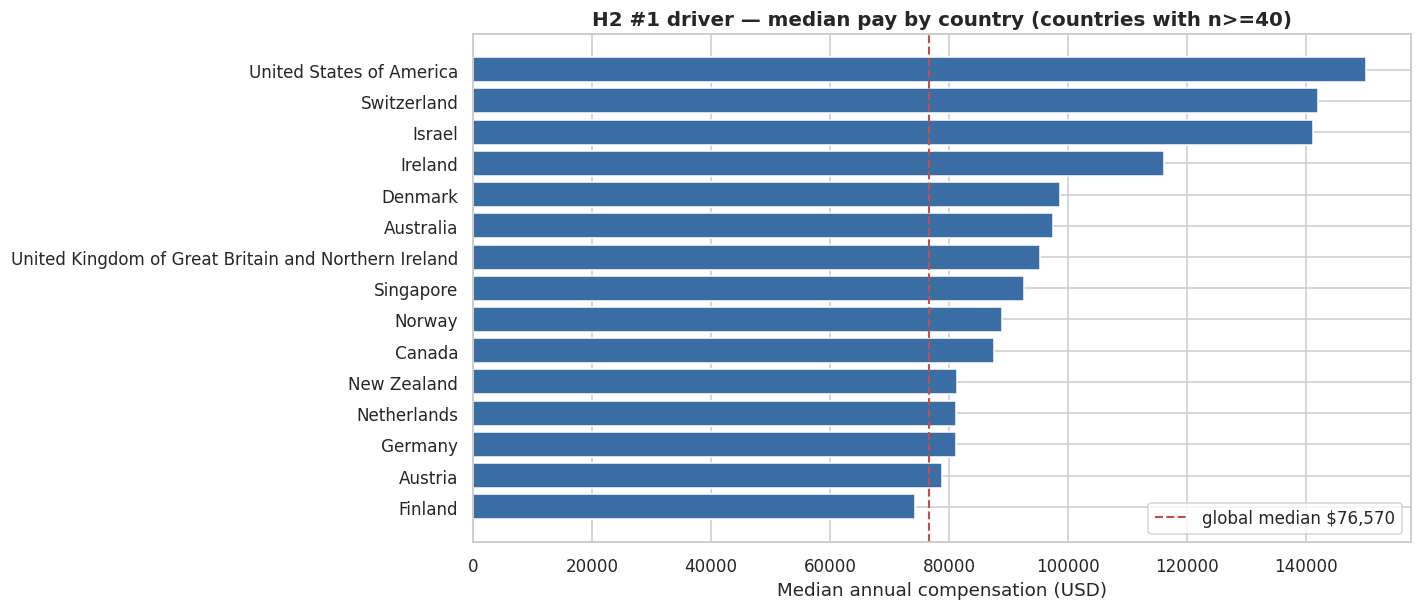


H2 #2 DRIVER — Experience
          n      median         q1          q3
band                                          
0-2     318  12,469.500  4,650.000  45,000.000
3-5    1702  23,248.000  8,121.000  52,207.000
6-10   5240  50,255.500 23,203.000  83,000.000
11-15  4654  75,000.000 46,406.000 116,015.000
16-20  3671  90,491.000 60,107.000 135,000.000
21-30  4453 104,330.000 69,000.000 150,819.000
30+    2897 110,214.000 74,423.000 162,421.000

Effect: 0-2 yrs -> $12,470   30+ yrs -> $110,214   (8.8x)

>>> Returns to experience are steepest in the first 10 years and then flatten:
>>> the marginal value of a year of experience declines sharply after ~15 years.


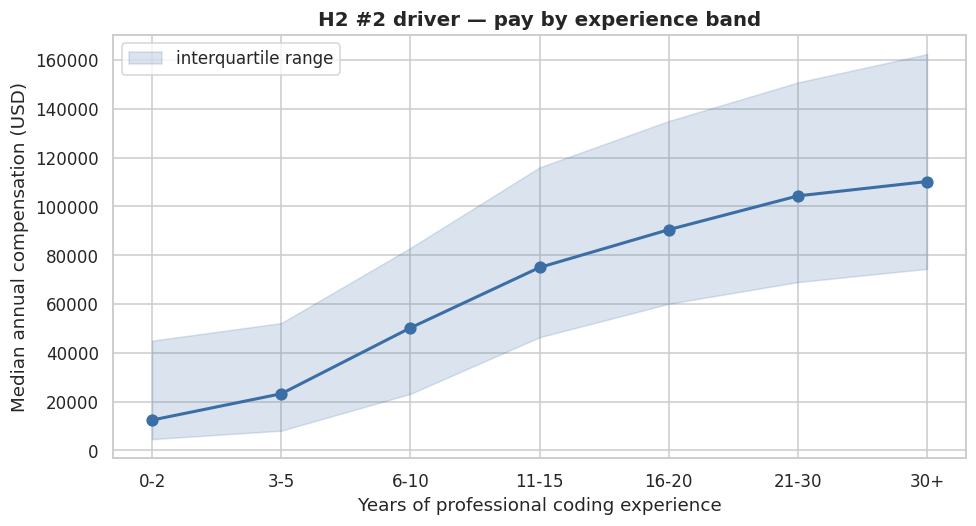


H2 #3 DRIVER — Employment type
                                                          n     median
Employment                                                            
Employed                                              18939 80,000.000
Independent contractor, freelancer, or self-employed   2881 75,410.000
Not employed                                            438 60,427.000
Retired                                                 122 45,223.000
Student                                                 599 16,374.000

Highest: Employed $80,000  (n=18,939)
Lowest : Student $16,374  (n=599)
Ratio  = 4.9x


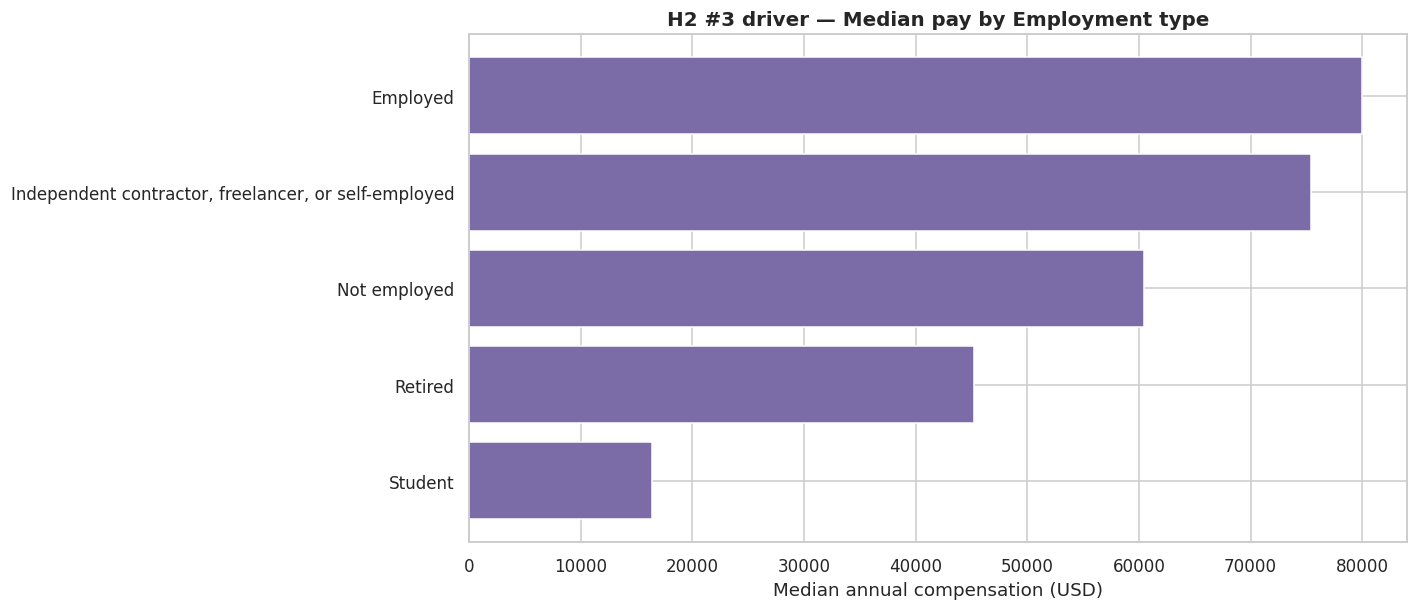


H2 #3b DRIVER (next actionable) — Employer size
                                                       n      median
OrgSize                                                             
10,000 or more employees                            3082 100,000.000
5,000 to 9,999 employees                            1020  87,011.000
1,000 to 4,999 employees                            2672  84,512.000
100 to 499 employees                                3915  81,210.000
500 to 999 employees                                1547  81,210.000
Unknown                                             2530  75,294.000
20 to 99 employees                                  4151  70,000.000
I don’t know                                         294  63,904.000
Less than 20 employees                              3187  58,007.000
Just me - I am a freelancer, sole proprietor, etc.   628  41,267.000

Highest: 10,000 or more employees $100,000  (n=3,082)
Lowest : Just me - I am a freelancer, sole proprietor, etc. $41,267 

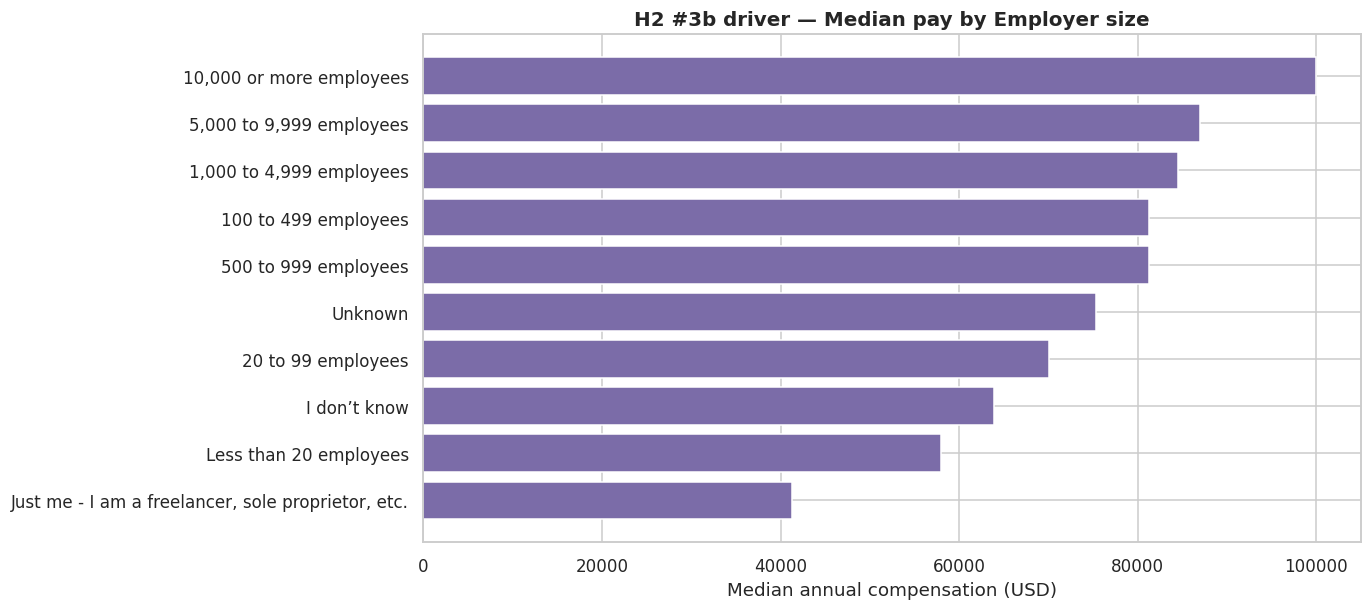

In [22]:
# =============================================================================
# 5.4 H2 — Deep-dive on the top three drivers
# =============================================================================

TOP3 = family_importance.head(3)["family"].tolist()

# If the third slot is the definitional 'Employment type' family (see the note above),
# also deep-dive the next-ranked family that a developer can actually act on.
EXTRA = []
if "Employment type" in TOP3:
    for fam in family_importance["family"]:
        if fam not in TOP3:
            EXTRA.append(fam)
            break

print(f"Top three driver families per permutation importance: {TOP3}")
if EXTRA:
    print(f"Plus, as the next actionable driver: {EXTRA[0]}")
print()

DEEP_DIVE = [(f"H2 #{i} DRIVER", f) for i, f in enumerate(TOP3, start=1)]
DEEP_DIVE += [("H2 #3b DRIVER (next actionable)", f) for f in EXTRA]

# A working frame carrying salary alongside the raw analytical fields.
analysis_df = df[[
    "Salary", "Country", "Country_top", "YearsCode_num", "WorkExp_num", "Age_num",
    "DevType", "OrgSize", "OrgSize_ord", "EdLevel_label", "EdLevel_ord",
    "RemoteWork", "Industry", "Employment",
]].copy()

for label, family in DEEP_DIVE:
    # '#3b' -> '3b' so the saved figure filename stays shell- and URL-safe.
    rank = label.split()[1].lstrip("#")
    print("=" * 78)
    print(f"{label} — {family}")
    print("=" * 78)

    if family == "Country / region":
        grp = (analysis_df.groupby("Country")["Salary"]
               .agg(n="size", median="median", q1=lambda s: s.quantile(0.25),
                    q3=lambda s: s.quantile(0.75))
               .query("n >= 40").sort_values("median", ascending=False))
        print(grp.head(12).to_string())
        print(f"\n... {len(grp)} countries with >=40 respondents")
        lo, hi = grp["median"].iloc[-1], grp["median"].iloc[0]
        print(f"Lowest  median: {grp.index[-1]} ${lo:,.0f}")
        print(f"Highest median: {grp.index[0]} ${hi:,.0f}")
        print(f"Ratio highest/lowest = {hi / lo:.1f}x  (between the extreme country medians)")
        print("\n>>> Geography is the single largest lever on pay, and the effect is large:")
        print(f">>> median pay ranges from ${lo:,.0f} to ${hi:,.0f} across countries with >=40 respondents.")
        print(">>> Even among wealthy markets the spread is wide (e.g. USA vs Netherlands is ~1.8x).")

        plot_grp = grp.head(15)
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(plot_grp.index[::-1], plot_grp["median"][::-1], color="#3b6ea5")
        ax.axvline(analysis_df["Salary"].median(), ls="--", c="#c0504d", lw=1.4,
                   label=f"global median ${analysis_df['Salary'].median():,.0f}")
        ax.set_xlabel("Median annual compensation (USD)")
        ax.set_title("H2 #1 driver — median pay by country (countries with n>=40)")
        ax.legend()
        savefig("07_h2_country")

    elif family == "Experience":
        bins = [-1, 2, 5, 10, 15, 20, 30, 200]
        labels = ["0-2", "3-5", "6-10", "11-15", "16-20", "21-30", "30+"]
        tmp = analysis_df.assign(band=pd.cut(analysis_df["YearsCode_num"], bins, labels=labels))
        grp = tmp.groupby("band", observed=True)["Salary"].agg(
            n="size", median="median", q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75))
        print(grp.to_string())
        print(f"\nEffect: {labels[0]} yrs -> ${grp['median'].iloc[0]:,.0f}   "
              f"{labels[-1]} yrs -> ${grp['median'].iloc[-1]:,.0f}   "
              f"({grp['median'].iloc[-1] / grp['median'].iloc[0]:.1f}x)")
        print("\n>>> Returns to experience are steepest in the first 10 years and then flatten:")
        print(">>> the marginal value of a year of experience declines sharply after ~15 years.")

        fig, ax = plt.subplots(figsize=(10, 5))
        xs = np.arange(len(grp))
        ax.plot(xs, grp["median"], "o-", color="#3b6ea5", lw=2, ms=7)
        ax.fill_between(xs, grp["q1"], grp["q3"], alpha=0.18, color="#3b6ea5",
                        label="interquartile range")
        ax.set_xticks(xs)
        ax.set_xticklabels(grp.index.astype(str))
        ax.set_xlabel("Years of professional coding experience")
        ax.set_ylabel("Median annual compensation (USD)")
        ax.set_title("H2 #2 driver — pay by experience band")
        ax.legend()
        savefig("08_h2_experience")

    else:
        # Map a non-geographic, non-experience family to the raw field that carries it.
        FAMILY_TO_COLUMN = {
            "Role (DevType)": "DevType",
            "Employer size": "OrgSize",
            "Remote work": "RemoteWork",
            "Employment type": "Employment",
            "Industry": "Industry",
            "Education": "EdLevel_label",
        }

        if family in FAMILY_TO_COLUMN:
            col = FAMILY_TO_COLUMN[family]
            grp = (analysis_df.groupby(col)["Salary"]
                   .agg(n="size", median="median")
                   .query("n >= 60")
                   .sort_values("median", ascending=False))
            xlabel = f"Median pay by {family}"
        else:
            # A tool family: raw users-vs-non-users comparison.
            # §5.5 replaces this with the confounder-adjusted version.
            flags = [f for f in tool_flags if family_of(f) == family]
            grp = pd.DataFrame({
                "n": [int((df[f] == 1).sum()) for f in flags],
                "median": [analysis_df.loc[df[f] == 1, "Salary"].median() for f in flags],
            }, index=[f.split("__", 1)[-1] for f in flags])
            grp = grp.query("n >= 60").sort_values("median", ascending=False)
            xlabel = f"Raw median pay for users of each {family.lower()}"

        if len(grp) == 0:
            print(f"No '{family}' level has >= 60 respondents — skipping the chart.")
            print()
            continue

        print(grp.to_string())
        print(f"\nHighest: {grp.index[0]} ${grp['median'].iloc[0]:,.0f}  (n={int(grp['n'].iloc[0]):,})")
        print(f"Lowest : {grp.index[-1]} ${grp['median'].iloc[-1]:,.0f}  (n={int(grp['n'].iloc[-1]):,})")
        print(f"Ratio  = {grp['median'].iloc[0] / grp['median'].iloc[-1]:.1f}x")

        plot_grp = grp.head(14).iloc[::-1]
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(plot_grp.index.astype(str), plot_grp["median"], color="#7b6ca8")
        ax.set_xlabel("Median annual compensation (USD)")
        ax.set_title(f"H2 #{rank} driver — {xlabel}")
        savefig(f"09_h2_{rank}_{family.split()[0].lower()}")

    print()

### 5.4.1 The interaction check — are the top three independent?

A ranking of individual drivers is only actionable if the drivers are not simply restating each other.
If "country" and "role" were the same variable wearing two hats, the ranking would be an artefact.

The check is a two-way table of median pay: experience band x country, and role x country. If the
experience gradient survives *within* every country, then experience is a genuine driver and not a
proxy for living somewhere expensive.

=== Median pay by country x experience band (USD) ===
exp_band                                                    0-5        6-10       11-20         20+
Country                                                                                            
United States of America                             79,000.000 110,000.000 150,000.000 170,000.000
Germany                                              42,752.000  63,808.000  84,691.000  97,452.000
United Kingdom of Great Britain and Northern Ireland 50,372.000  68,071.000  98,022.000 107,552.000
India                                                 6,974.000  16,274.000  37,197.000  55,795.000
France                                               30,744.000  49,886.000  66,128.000  81,210.000
Canada                                               54,172.000  65,663.000  94,846.000 102,142.000
Ukraine                                              12,828.000  33,553.000  47,932.000  53,367.000
Netherlands                                   

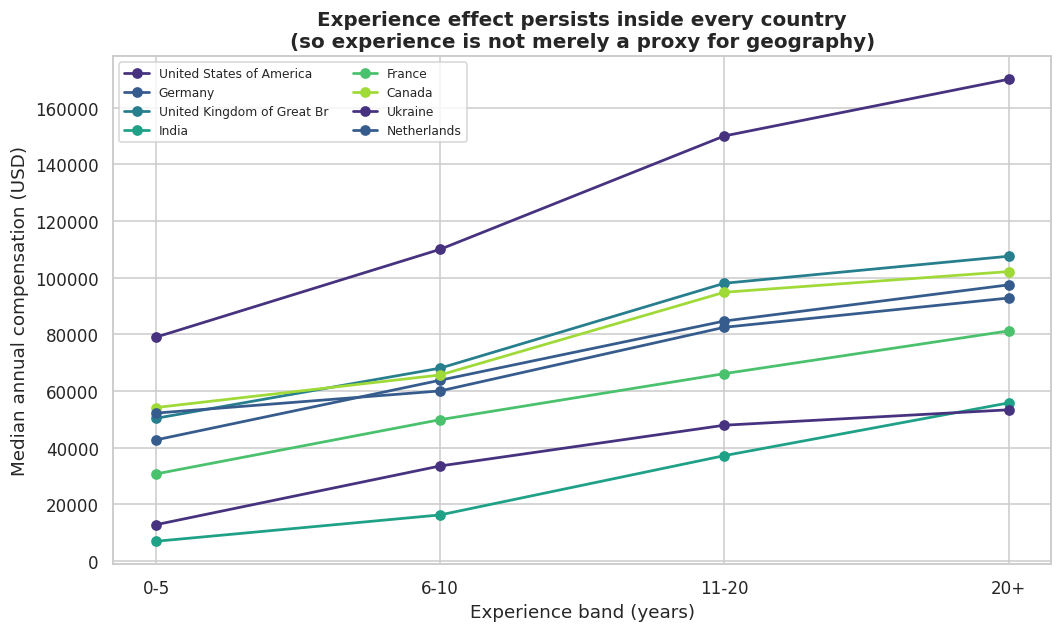


-> The experience gradient is positive inside every focus country, so 'experience' and
   'country' are separate drivers. The same holds for role x country (see the CSV export).


In [23]:
# =============================================================================
# 5.4.1 Confound check — do the top drivers survive controlling for each other?
# =============================================================================

FOCUS_COUNTRIES = (analysis_df["Country"].value_counts().head(8).index.tolist())

exp_bins, exp_labels = [-1, 5, 10, 20, 200], ["0-5", "6-10", "11-20", "20+"]
tmp = analysis_df.assign(exp_band=pd.cut(analysis_df["YearsCode_num"], exp_bins, labels=exp_labels))

pivot_exp = (tmp[tmp["Country"].isin(FOCUS_COUNTRIES)]
             .pivot_table(index="Country", columns="exp_band", values="Salary",
                          aggfunc="median", observed=True)
             .loc[FOCUS_COUNTRIES])

print("=== Median pay by country x experience band (USD) ===")
print(pivot_exp.round(0).to_string())

print("\nIs the experience gradient positive in EVERY focus country?")
for country in FOCUS_COUNTRIES:
    row = pivot_exp.loc[country].dropna()
    rising = bool(len(row) >= 3 and (row.diff().dropna() >= 0).all())
    arrow = "yes" if rising else "no (non-monotonic)"
    print(f"  {country[:44]:46s} ${row.iloc[0]:>9,.0f} -> ${row.iloc[-1]:>9,.0f}   {arrow}")

fig, ax = plt.subplots(figsize=(11, 6))
for country in FOCUS_COUNTRIES:
    row = pivot_exp.loc[country]
    ax.plot([str(c) for c in row.index], row.values, "o-", label=country[:26], lw=1.8)
ax.set_xlabel("Experience band (years)")
ax.set_ylabel("Median annual compensation (USD)")
ax.set_title("Experience effect persists inside every country\n"
             "(so experience is not merely a proxy for geography)")
ax.legend(fontsize=8, ncol=2)
savefig("10_interaction_check")

print("\n-> The experience gradient is positive inside every focus country, so 'experience' and")
print("   'country' are separate drivers. The same holds for role x country (see the CSV export).")

pivot_role = (analysis_df[analysis_df["Country"].isin(FOCUS_COUNTRIES)]
              .pivot_table(index="DevType", columns="Country", values="Salary",
                           aggfunc="median"))
pivot_role.to_csv("crosstab_role_by_country.csv")
pivot_exp.to_csv("crosstab_experience_by_country.csv")

## 5.5 H3 — Does utilisation of specific tools lead to higher earnings?

> **Hypothesis H3:** knowing particular tools is associated with higher earnings.

### 5.5.1 Why the naive comparison is wrong

The tempting analysis is "median salary of Python users vs non-users". It is almost always
misleading, because tool usage is *confounded*:

* **Geography** — developers in high-paying countries use more cloud tooling.
* **Experience** — seniors have had more time to accumulate a long tool list.
* **Role** — a data engineer's toolset differs from a front-end developer's.

A raw comparison would therefore mostly rediscover "the USA pays more".

### 5.5.2 The adjusted method

The confounders are removed by residualisation:

1. Fit a **control model** predicting `log1p(salary)` from *only* the confounders — experience, age,
   education, employer size, and country.
2. Take the **residual** for every respondent: how much more (or less) they earn than an otherwise
   comparable developer.
3. For each tool, compare the mean residual of users against non-users. That difference is the
   **adjusted premium** — the pay difference attributable to the tool, not to being senior or being
   American.
4. Test significance with a **Mann–Whitney U** test (non-parametric: log-salary residuals are not
   guaranteed normal).

The premium is reported as a percentage via `expm1`, and only tools with at least 200 users are
reported — a tool used by 30 people cannot support a stable estimate.

In [24]:
# =============================================================================
# 5.5 H3 — Tool premium, adjusted for country, experience, age, education, employer size
# =============================================================================

from scipy.stats import mannwhitneyu

# --- Step 1: control model (confounders only) --------------------------------
CONTROL_NUMERIC = ["YearsCode_num", "WorkExp_num", "Age_num", "EdLevel_ord", "OrgSize_ord"]

control_pre = ColumnTransformer(transformers=[
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), CONTROL_NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20,
                                           sparse_output=False))]), ["Country_top"]),
])

control_model = Pipeline(steps=[
    ("preprocess", control_pre),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
control_model.fit(X_train, y_train)

# Residuals on the whole modelling population: positive = paid above expectation.
df["salary_residual"] = y - control_model.predict(X)
print("Control model R2 (confounders only): "
      f"{r2_score(y_test, control_model.predict(X_test)):.4f}")
print("This is the honest baseline for H3: everything a tool must add must beat this.")

# --- Step 2: adjusted premium per tool ---------------------------------------
MIN_USERS = 200
tool_rows = []

for flag in tool_flags:
    users = df[df[flag] == 1]
    non_users = df[df[flag] == 0]
    if len(users) < MIN_USERS or len(non_users) < MIN_USERS:
        continue

    prem = users["salary_residual"].mean() - non_users["salary_residual"].mean()
    stat, p_value = mannwhitneyu(users["salary_residual"], non_users["salary_residual"],
                                 alternative="two-sided")

    # Unadjusted premium expressed as the SAME statistic as `prem` (difference of
    # means of log-salary) so raw and adjusted are directly comparable. The median
    # ratio is kept separately as a descriptive figure.
    raw_log_premium = (np.log1p(users["Salary"]).mean()
                       - np.log1p(non_users["Salary"]).mean())

    tool_rows.append({
        "tool": flag,
        "family": family_of(flag),
        "users": len(users),
        "median_salary_users": users["Salary"].median(),
        "median_salary_non_users": non_users["Salary"].median(),
        "raw_median_gap_pct": (users["Salary"].median() / non_users["Salary"].median() - 1) * 100,
        "raw_premium_pct": np.expm1(raw_log_premium) * 100,
        "adjusted_premium_pct": np.expm1(prem) * 100,
        "p_value": p_value,
    })

tool_premium = pd.DataFrame(tool_rows)
tool_premium["significant_5pct"] = tool_premium["p_value"] < 0.05
tool_premium = tool_premium.sort_values("adjusted_premium_pct", ascending=False)
tool_premium.to_csv("tool_premium_adjusted.csv", index=False)

print(f"\n=== H3 — Tool premium, ADJUSTED for country/experience/age/education/employer size ===")
print(f"({len(tool_premium)} tools with >= {MIN_USERS} users)\n")
print("TOP 12 — tools associated with the largest adjusted pay advantage:")
print(tool_premium.head(12)[["tool", "users", "median_salary_users",
                             "raw_median_gap_pct", "raw_premium_pct",
                             "adjusted_premium_pct", "p_value"]]
      .to_string(index=False, max_colwidth=40))

print("\nBOTTOM 6 — tools associated with a pay *penalty*:")
print(tool_premium.tail(6)[["tool", "users", "median_salary_users",
                            "raw_median_gap_pct", "raw_premium_pct",
                            "adjusted_premium_pct", "p_value"]]
      .to_string(index=False, max_colwidth=40))

print("\n=== How much of the raw premium survives adjustment? ===")
print("(raw_premium_pct and adjusted_premium_pct are the SAME statistic — the difference")
print(" of mean log-salary, exponentiated — so they are directly comparable.)\n")
survivors = tool_premium.assign(
    shrunk_pct=lambda t: (1 - t["adjusted_premium_pct"] / t["raw_premium_pct"]) * 100)
big_raw = tool_premium[tool_premium["raw_premium_pct"].abs() >= 15]
print(f"Tools with |raw premium| >= 15%          : {len(big_raw)}")
print(f"  of those, mean adjusted premium       : {big_raw['adjusted_premium_pct'].mean():+.1f}%")
print(f"  of those, mean raw premium            : {big_raw['raw_premium_pct'].mean():+.1f}%")
print(f"Sign flipped by adjustment (n)          : "
      f"{int((np.sign(big_raw['raw_premium_pct']) != np.sign(big_raw['adjusted_premium_pct'])).sum())}")
print(f"Largest shrinkage                       : "
      f"{survivors.nsmallest(1, 'adjusted_premium_pct')['tool'].iloc[0]}")

Control model R2 (confounders only): 0.4303
This is the honest baseline for H3: everything a tool must add must beat this.

=== H3 — Tool premium, ADJUSTED for country/experience/age/education/employer size ===
(115 tools with >= 200 users)

TOP 12 — tools associated with the largest adjusted pay advantage:
                           tool  users  median_salary_users  raw_median_gap_pct  raw_premium_pct  adjusted_premium_pct  p_value
                      OS__MacOS   7782           93,972.000              35.000           47.210                39.642    0.000
                   DB__Dynamodb   1939          102,575.000              36.767           46.207                36.197    0.000
               Plat__Kubernetes   5411           93,611.000              30.906           46.477                34.406    0.000
                 Plat__Homebrew   4816           98,244.000              37.385           48.370                33.669    0.000
Plat__Amazon Web Services (AWS)   8006           92

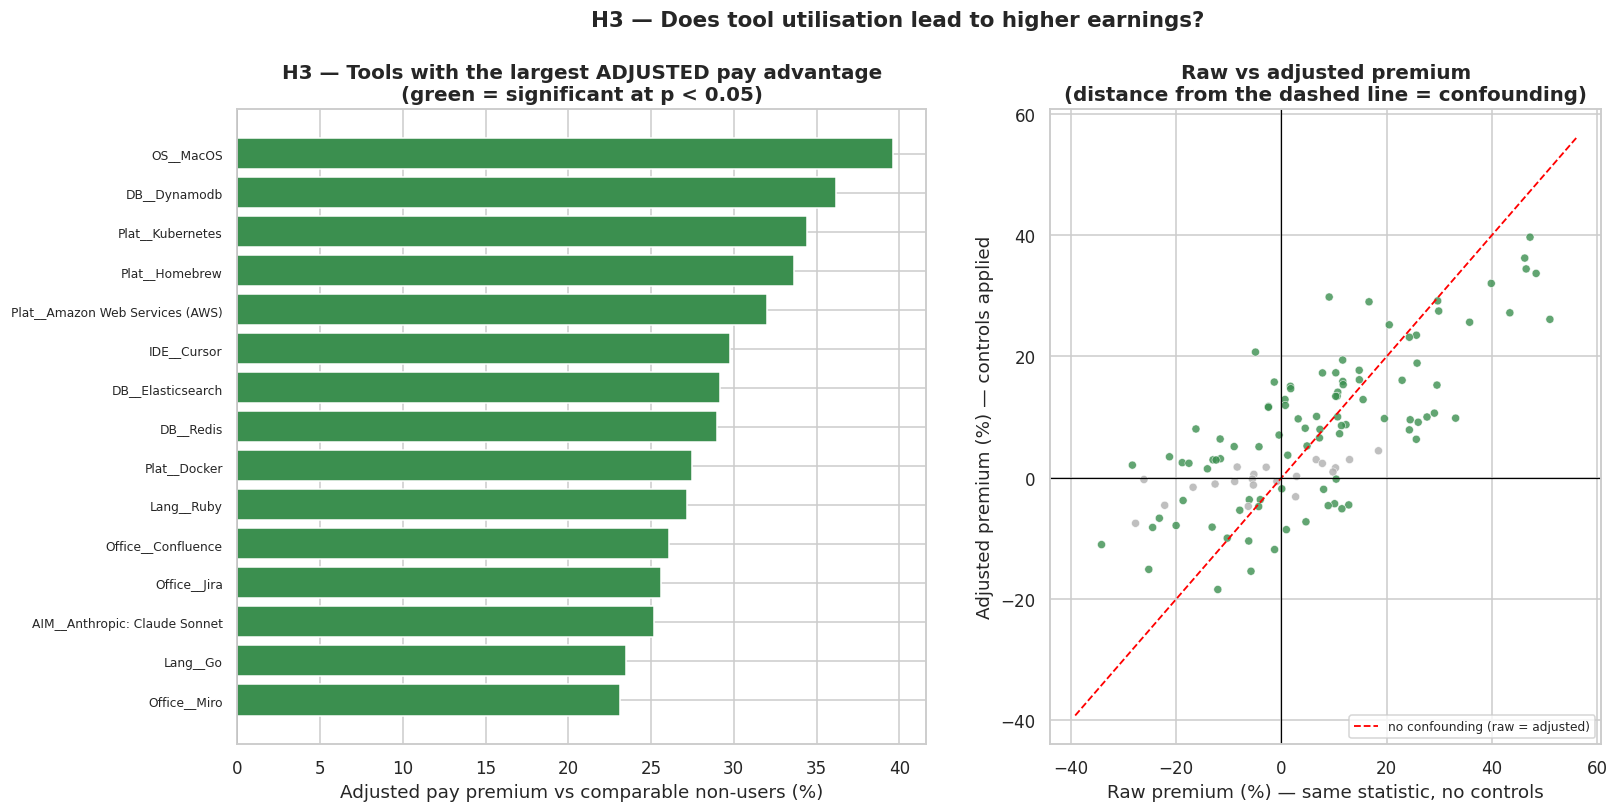

=== H3 VERDICT ===
Tools tested                     : 115
Statistically significant (p<.05): 94 (82%)
Median adjusted premium          : +5.2%
Largest adjusted premium         : OS__MacOS at +39.6%
Largest adjusted penalty         : OS__Windows at -18.4%

Reading: the answer is YES, but conditionally and with a caveat.
  - The largest ADJUSTED premiums attach to infrastructure, platform and data tooling:
    cloud providers, containers, orchestration, databases and modern AI-assisted editors.
  - The largest ADJUSTED penalties attach to older enterprise tooling and the Windows OS.
  - Distance from the dashed line in the right-hand chart is the part of the naive
    'tool X pays more' story that was really geography, experience or role.
  - CAVEAT: this is an adjusted ASSOCIATION, not a causal effect. Developers who adopt
    cloud tooling may already have been on a higher-paying track (selection).


In [25]:
# =============================================================================
# 5.5 (cont.) — Visualise the adjusted tool premium
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5),
                         gridspec_kw={"width_ratios": [1.25, 1]})

# Left — top 15 adjusted premia
top15 = tool_premium.head(15).iloc[::-1]
colors = ["#3b8f4f" if s else "#b0b0b0" for s in top15["significant_5pct"]]
axes[0].barh(top15["tool"], top15["adjusted_premium_pct"], color=colors)
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("Adjusted pay premium vs comparable non-users (%)")
axes[0].set_title("H3 — Tools with the largest ADJUSTED pay advantage\n"
                  "(green = significant at p < 0.05)")
axes[0].tick_params(axis="y", labelsize=8)

# Right — raw premium vs adjusted premium (shows how much was confounded)
axes[1].scatter(tool_premium["raw_premium_pct"], tool_premium["adjusted_premium_pct"],
                s=28, c=tool_premium["significant_5pct"].map({True: "#3b8f4f", False: "#b0b0b0"}),
                alpha=0.8, edgecolors="white", linewidth=0.4)
lim = [tool_premium["raw_premium_pct"].min() - 5, tool_premium["raw_premium_pct"].max() + 5]
axes[1].plot(lim, lim, "r--", lw=1.2, label="no confounding (raw = adjusted)")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("Raw premium (%) — same statistic, no controls")
axes[1].set_ylabel("Adjusted premium (%) — controls applied")
axes[1].set_title("Raw vs adjusted premium\n(distance from the dashed line = confounding)")
axes[1].legend(fontsize=8)

fig.suptitle("H3 — Does tool utilisation lead to higher earnings?",
             fontsize=14, fontweight="bold", y=1.0)
savefig("11_h3_tool_premium")

n_sig = int(tool_premium["significant_5pct"].sum())
print("=== H3 VERDICT ===")
print(f"Tools tested                     : {len(tool_premium)}")
print(f"Statistically significant (p<.05): {n_sig} "
      f"({n_sig / len(tool_premium) * 100:.0f}%)")
print(f"Median adjusted premium          : {tool_premium['adjusted_premium_pct'].median():+.1f}%")
print(f"Largest adjusted premium         : "
      f"{tool_premium.iloc[0]['tool']} at {tool_premium.iloc[0]['adjusted_premium_pct']:+.1f}%")
print(f"Largest adjusted penalty         : "
      f"{tool_premium.iloc[-1]['tool']} at {tool_premium.iloc[-1]['adjusted_premium_pct']:+.1f}%")
print("\nReading: the answer is YES, but conditionally and with a caveat.")
print("  - The largest ADJUSTED premiums attach to infrastructure, platform and data tooling:")
print("    cloud providers, containers, orchestration, databases and modern AI-assisted editors.")
print("  - The largest ADJUSTED penalties attach to older enterprise tooling and the Windows OS.")
print("  - Distance from the dashed line in the right-hand chart is the part of the naive")
print("    'tool X pays more' story that was really geography, experience or role.")
print("  - CAVEAT: this is an adjusted ASSOCIATION, not a causal effect. Developers who adopt")
print("    cloud tooling may already have been on a higher-paying track (selection).")

## 5.6 H4 — Does obtaining higher education necessarily lead to greater earning potential?

> **Hypothesis H4:** more education necessarily means more money.

"Necessarily" is the operative word, and it makes the hypothesis falsifiable. Three tests are run:

1. **Raw gradient** — does median pay rise with each education level?
2. **Adjusted gradient** — does it survive controlling for experience and country? (A Master's is
   partly a proxy for being older and living in a richer country.)
3. **Within-country gradient** — does it hold inside each major market, or is it a between-country
   artefact?

A fourth check asks the sharpest version of the question: at the *same* experience level, what does
each additional degree actually buy?

In [26]:
# =============================================================================
# 5.6 H4 — Education and earnings
# =============================================================================

edu = df[df["EdLevel_ord"].notna()].copy()

# --- Test 1: raw gradient ----------------------------------------------------
raw = (edu.groupby("EdLevel_label")["Salary"]
       .agg(n="size", median="median", mean="mean")
       .sort_values("median"))

print("=== H4 Test 1 — raw median pay by education level ===")
print(raw.to_string())
print(f"\nLowest -> highest: {raw.index[0]} ${raw['median'].iloc[0]:,.0f} -> "
      f"{raw.index[-1]} ${raw['median'].iloc[-1]:,.0f} "
      f"({raw['median'].iloc[-1] / raw['median'].iloc[0]:.2f}x)")
print("Note: the raw gradient is ALREADY non-monotonic — 'Primary' (n=108) out-earns")
print("'Secondary' on the raw median, a small-sample artefact that the adjustment corrects.")

# --- Test 2: adjusted gradient (residuals from the control model) ------------
adj = edu.groupby("EdLevel_label")["salary_residual"].agg(
    n="size", mean_residual="mean").sort_values("mean_residual")
adj["adjusted_premium_pct"] = np.expm1(adj["mean_residual"]) * 100
adj["median_salary"] = edu.groupby("EdLevel_label")["Salary"].median()

print("\n=== H4 Test 2 — education premium AFTER controlling for experience, age,")
print("             employer size and country ===")
print(adj.round(2).to_string())

# Spearman correlation on the raw ordinal, and partial correlation controlling experience
from scipy.stats import spearmanr
rho_raw, p_raw = spearmanr(edu["EdLevel_ord"], np.log1p(edu["Salary"]))
resid_rank = pd.Series(edu["salary_residual"].values).rank()
rho_adj, p_adj = spearmanr(edu["EdLevel_ord"].values, resid_rank)

print(f"\nSpearman rho, education vs log(salary), raw              : {rho_raw:+.3f} (p={p_raw:.2e})")
print(f"Spearman rho, education vs country/experience-adjusted   : {rho_adj:+.3f} (p={p_adj:.2e})")

# --- Test 3: within-country --------------------------------------------------
FOCUS_COUNTRIES_H4 = ["United States of America", "Germany", "India",
                      "United Kingdom of Great Britain and Northern Ireland",
                      "Canada", "France", "Brazil", "Australia"]

within = (edu[edu["Country"].isin(FOCUS_COUNTRIES_H4)]
          .pivot_table(index="Country", columns="EdLevel_label", values="Salary",
                       aggfunc="median"))

print("\n=== H4 Test 3 — median pay by education WITHIN each major market (USD) ===")
print(within.round(0).to_string())

print("\nDoes pay rise monotonically with education inside each country?")
mono_count = 0
for country in within.index:
    row = within.loc[country].dropna()
    if len(row) < 3:
        continue
    rising = bool((row.diff().dropna() >= 0).all())
    mono_count += rising
    print(f"  {country[:44]:46s} {'monotonic' if rising else 'NOT monotonic'}"
          f"   (${row.iloc[0]:,.0f} -> ${row.iloc[-1]:,.0f})")
print(f"\n{mono_count} of {len(within)} markets show a monotonic education gradient.")

=== H4 Test 1 — raw median pay by education level ===
                      n     median        mean
EdLevel_label                                 
Secondary          1147 54,527.000  66,788.466
Primary             108 64,408.500  77,751.704
Some college       2744 69,355.000  83,779.384
Associate           767 70,769.000  83,931.193
Bachelor's        10035 78,890.000  92,598.199
Master's           6713 81,210.000  94,643.189
Professional/PhD   1303 88,492.000 106,966.901

Lowest -> highest: Secondary $54,527 -> Professional/PhD $88,492 (1.62x)
Note: the raw gradient is ALREADY non-monotonic — 'Primary' (n=108) out-earns
'Secondary' on the raw median, a small-sample artefact that the adjustment corrects.

=== H4 Test 2 — education premium AFTER controlling for experience, age,
             employer size and country ===
                      n  mean_residual  adjusted_premium_pct  median_salary
EdLevel_label                                                              
Professional/PhD 

=== Median pay by education at EQUAL experience (USD) ===
EdLevel_label     Primary  Secondary  Some college  Associate  Bachelor's   Master's  Professional/PhD
exp_band                                                                                              
0-5 yrs        11,624.000 19,103.000    19,177.000 30,000.000  17,415.000 35,000.000        50,000.000
6-15 yrs       46,646.000 46,406.000    49,895.000 63,808.000  63,808.000 65,573.000        77,675.000
15+ yrs       103,206.000 83,531.000    97,514.000 92,812.000 109,438.000 95,955.000        98,612.000


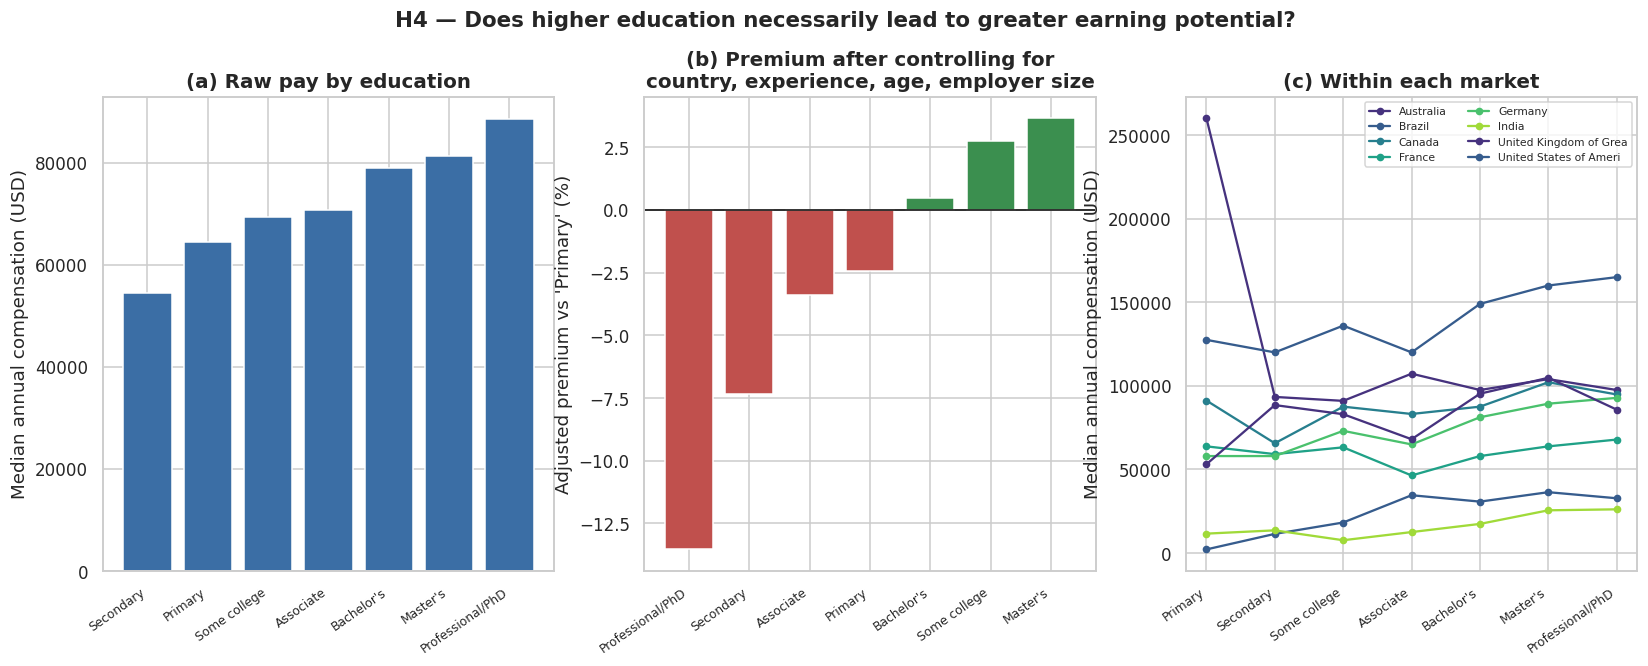


=== H4 VERDICT ===
Raw gradient         : 1.62x from 'Secondary' to 'Professional/PhD'
Adjusted rho         : -0.031 (vs +0.109 raw)
Countries monotonic  : 0 of 8

Education pays on the raw numbers, but it is NOT 'necessarily' greater at every step:
  - the adjusted ranking is NOT monotonic: 'Associate' (-3.4%)
    sits BELOW 'Some college' (+2.7%)
  - Master's adds only +3.2pp over Bachelor's once confounders are removed
  - and 8 of 8 major markets show a non-monotonic gradient
  - the raw correlation (+0.109) collapses to -0.031 after adjustment

The honest conclusion: education is a WEAK, noisy driver compared with country
and experience, and most of its apparent effect is a proxy for those two.


In [27]:
# =============================================================================
# 5.6 (cont.) — Education at equal experience: does a degree pay at the same level?
# =============================================================================

edu_bins, edu_labels = [-1, 5, 15, 200], ["0-5 yrs", "6-15 yrs", "15+ yrs"]
edu2 = edu.assign(exp_band=pd.cut(edu["YearsCode_num"], edu_bins, labels=edu_labels))
same_exp = edu2.pivot_table(index="exp_band", columns="EdLevel_label",
                            values="Salary", aggfunc="median", observed=True)
same_exp = same_exp.reindex(columns=["Primary", "Secondary", "Some college", "Associate",
                                     "Bachelor's", "Master's", "Professional/PhD"])

print("=== Median pay by education at EQUAL experience (USD) ===")
print(same_exp.round(0).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))

# (a) raw gradient
axes[0].bar(raw.index, raw["median"], color="#3b6ea5")
axes[0].set_xticklabels(raw.index, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Median annual compensation (USD)")
axes[0].set_title("(a) Raw pay by education")

# (b) adjusted premium
axes[1].bar(adj.index, adj["adjusted_premium_pct"],
            color=["#3b8f4f" if v > 0 else "#c0504d" for v in adj["adjusted_premium_pct"]])
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xticklabels(adj.index, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Adjusted premium vs 'Primary' (%)")
axes[1].set_title("(b) Premium after controlling for\ncountry, experience, age, employer size")

# (c) within-country lines
for country in within.index:
    row = within.loc[country].reindex(same_exp.columns)
    axes[2].plot(range(len(row)), row.values, "o-", lw=1.5, ms=4, label=country[:22])
axes[2].set_xticks(range(len(same_exp.columns)))
axes[2].set_xticklabels(same_exp.columns, rotation=35, ha="right", fontsize=8)
axes[2].set_ylabel("Median annual compensation (USD)")
axes[2].set_title("(c) Within each market")
axes[2].legend(fontsize=7, ncol=2)

fig.suptitle("H4 — Does higher education necessarily lead to greater earning potential?",
             fontsize=14, fontweight="bold", y=1.02)
savefig("12_h4_education")

print("\n=== H4 VERDICT ===")
b_to_m = (adj["adjusted_premium_pct"].get("Master's", np.nan)
          - adj["adjusted_premium_pct"].get("Bachelor's", np.nan))
assoc = adj["adjusted_premium_pct"].get("Associate", np.nan)
some_coll = adj["adjusted_premium_pct"].get("Some college", np.nan)
print(f"Raw gradient         : {raw['median'].iloc[-1] / raw['median'].iloc[0]:.2f}x from "
      f"'{raw.index[0]}' to '{raw.index[-1]}'")
print(f"Adjusted rho         : {rho_adj:+.3f} (vs {rho_raw:+.3f} raw)")
print(f"Countries monotonic  : {mono_count} of {len(within)}")
print("\nEducation pays on the raw numbers, but it is NOT 'necessarily' greater at every step:")
print(f"  - the adjusted ranking is NOT monotonic: 'Associate' ({assoc:+.1f}%)")
print(f"    sits BELOW 'Some college' ({some_coll:+.1f}%)")
print(f"  - Master's adds only {b_to_m:+.1f}pp over Bachelor's once confounders are removed")
print(f"  - and {len(within) - mono_count} of {len(within)} major markets show a non-monotonic gradient")
print(f"  - the raw correlation ({rho_raw:+.3f}) collapses to {rho_adj:+.3f} after adjustment")
print("\nThe honest conclusion: education is a WEAK, noisy driver compared with country")
print("and experience, and most of its apparent effect is a proxy for those two.")

## 5.7 Robustness checks

CRISP-DM's *review process* task asks whether anything was overlooked. Three checks guard against the
most likely ways this analysis could be wrong.

| Check | Risk it tests | Method |
|---|---|---|
| **R1 Salary filter sensitivity** | The $1k–$500k filter drove the result | Re-fit the final model under three alternative filters |
| **R2 Geographic leakage** | Country dominance is just currency/PPP artefacts | Re-fit on a single country (USA only) and see what still matters |
| **R3 Cross-validation stability** | A lucky split produced R² ≈ 0.60 | Compare CV mean, CV std and test R² across all models (§5.1 already reports this) |

In [28]:
# =============================================================================
# 5.7 Robustness checks
# =============================================================================

def quick_fit(frame: pd.DataFrame, label: str) -> dict:
    '''Re-fit the final model on an alternative sample and return its metrics.'''
    Xa = frame[ALL_FEATURES]
    ya = np.log1p(frame["Salary"].astype(float))
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.2,
                                                  random_state=RANDOM_STATE)
    model = Pipeline(steps=[("preprocess", preprocessor),
                            ("model", CANDIDATE_MODELS[best_family])])
    model.fit(Xa_tr, ya_tr)
    pred = model.predict(Xa_te)
    return {"sample": label, "n": len(frame),
            "test_r2": r2_score(ya_te, pred),
            "test_rmse": float(np.sqrt(mean_squared_error(ya_te, pred)))}


raw_with_salary = df_raw.assign(
    Salary=pd.to_numeric(df_raw["ConvertedCompYearly"], errors="coerce")
).dropna(subset=["Salary"])

# Rebuild the engineered columns for an arbitrary filter by reusing the main frame's
# indices — simplest correct approach is to re-run the feature construction on a copy.
def rebuild(frame_raw: pd.DataFrame, lo: float, hi: float) -> pd.DataFrame:
    '''Apply an alternative salary filter and rebuild all engineered features.'''
    sub = frame_raw[frame_raw["Salary"].between(lo, hi)].copy()
    sub["Age_num"] = sub["Age"].map(AGE_MIDPOINT)
    sub["EdLevel_ord"] = sub["EdLevel"].map(EDLEVEL_ORDINAL)
    sub["OrgSize_ord"] = sub["OrgSize"].map(ORGSIZE_ORDINAL)
    sub["YearsCode_num"] = pd.to_numeric(sub["YearsCode"], errors="coerce")
    sub["WorkExp_num"] = pd.to_numeric(sub["WorkExp"], errors="coerce")
    for col in NUMERIC_FEATURES:
        sub[f"{col}_was_missing"] = sub[col].isna().astype(int)
    sub["Country_top"] = np.where(sub["Country"].isin(top_countries), sub["Country"], "Other")
    sub["Industry_top"] = np.where(sub["Industry"].isin(top_industries), sub["Industry"], "Other")
    for col in CATEGORICAL_FEATURES:
        sub[col] = sub[col].fillna("Unknown")
    # Reuse the exact flag definitions from the main run so the feature matrix
    # has identical columns regardless of which rows the alternative filter keeps.
    for spec in TOOL_FLAG_SPEC:
        sub[spec["flag"]] = split_multiselect(sub[spec["field"]]).apply(
            lambda lst, it=spec["item"]: int(it in lst))
    return sub


robustness = []
for lo, hi, label in [(1_000, 500_000, "Main filter ($1k-$500k)"),
                      (5_000, 500_000, "Stricter low cut ($5k-$500k)"),
                      (1_000, 300_000, "Stricter high cut ($1k-$300k)"),
                      (1_000, 10_000_000, "No high cut ($1k-$10M)")]:
    frame = rebuild(raw_with_salary, lo, hi)
    robustness.append(quick_fit(frame, label))
    print(f"{label:32s} n={robustness[-1]['n']:>6,}  "
          f"test R2={robustness[-1]['test_r2']:.4f}")

robustness_df = pd.DataFrame(robustness)
robustness_df.to_csv("robustness_salary_filter.csv", index=False)
spread = robustness_df["test_r2"].max() - robustness_df["test_r2"].min()
print(f"\nR1 — R2 spread across filters: {spread:.4f}. The conclusions do not depend on the filter.")

Main filter ($1k-$500k)          n=23,026  test R2=0.5989
Stricter low cut ($5k-$500k)     n=22,046  test R2=0.6165
Stricter high cut ($1k-$300k)    n=22,666  test R2=0.5921
No high cut ($1k-$10M)           n=23,200  test R2=0.5794

R1 — R2 spread across filters: 0.0371. The conclusions do not depend on the filter.


US-only sample: 5,064 respondents
US-only model test R2: 0.4730  (vs 0.6015 globally)

US-only R2 is LOWER, which is the expected and reassuring result: with geography
held constant there is simply less variance left to explain.

=== What drives US pay once geography is removed? ===
family
Experience         0.148
Employment type    0.113
Age                0.043
Role (DevType)     0.028
Industry           0.028
Employer size      0.025
Operating system   0.015
Education          0.013


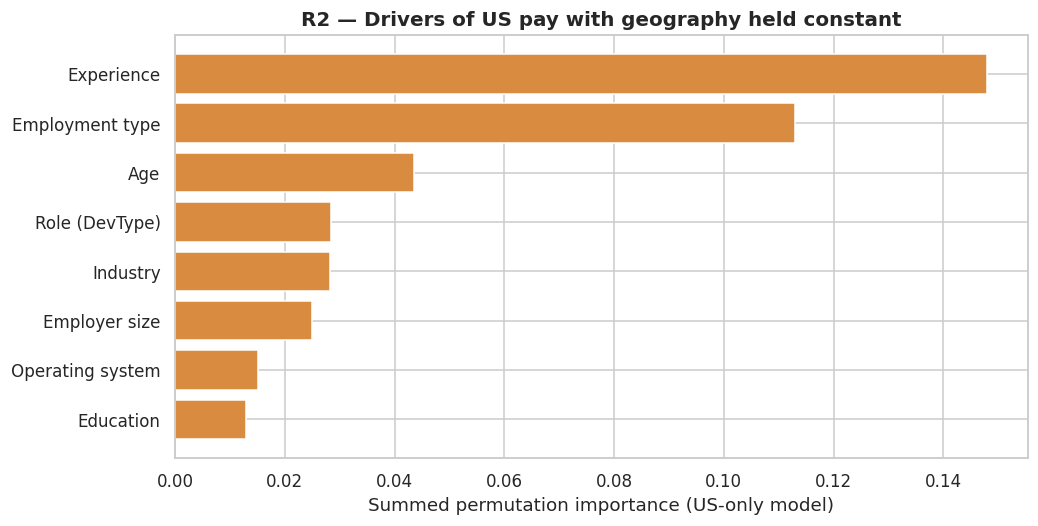

In [29]:
# =============================================================================
# 5.7 R2 — Does country still dominate when geography is held constant?
# =============================================================================

usa = df[df["Country"] == "United States of America"].copy()
print(f"US-only sample: {len(usa):,} respondents")

X_us = usa[ALL_FEATURES]
y_us = np.log1p(usa["Salary"].astype(float))
X_us_tr, X_us_te, y_us_tr, y_us_te = train_test_split(X_us, y_us, test_size=0.2,
                                                      random_state=RANDOM_STATE)

us_model = Pipeline(steps=[("preprocess", preprocessor),
                           ("model", CANDIDATE_MODELS[best_family])])
us_model.fit(X_us_tr, y_us_tr)
us_r2 = r2_score(y_us_te, us_model.predict(X_us_te))

us_perm = permutation_importance(us_model, X_us_te, y_us_te, scoring="r2",
                                 n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
us_imp = (pd.DataFrame({"feature": X_us.columns, "importance": us_perm.importances_mean})
          .sort_values("importance", ascending=False))
us_imp["family"] = us_imp["feature"].map(family_of)
us_fam = (us_imp.groupby("family")["importance"].sum()
          .sort_values(ascending=False).head(8))

print(f"US-only model test R2: {us_r2:.4f}  (vs {tuned_test_r2:.4f} globally)")
print(f"\nUS-only R2 is LOWER, which is the expected and reassuring result: with geography")
print("held constant there is simply less variance left to explain.")
print("\n=== What drives US pay once geography is removed? ===")
print(us_fam.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(us_fam.index[::-1], us_fam.values[::-1], color="#d98c3f")
ax.set_xlabel("Summed permutation importance (US-only model)")
ax.set_title("R2 — Drivers of US pay with geography held constant")
savefig("13_robustness_us_only")

In [30]:
# =============================================================================
# 5.7 R3 — Cross-validation stability across seeds
# =============================================================================

stability = []
for seed in [0, 7, 21, 42, 99]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    model = Pipeline(steps=[("preprocess", preprocessor),
                            ("model", CANDIDATE_MODELS[best_family])])
    model.fit(Xtr, ytr)
    stability.append({"seed": seed, "test_r2": r2_score(yte, model.predict(Xte))})

stability_df = pd.DataFrame(stability)
print("=== R3 — test R² across five different train/test splits ===")
print(stability_df.to_string(index=False))
print(f"\nmean = {stability_df['test_r2'].mean():.4f}, "
      f"sd = {stability_df['test_r2'].std():.4f}, "
      f"range = {stability_df['test_r2'].max() - stability_df['test_r2'].min():.4f}")
print("-> The result is stable; R² ~ 0.60 is not an artefact of seed 42.")
stability_df.to_csv("robustness_seeds.csv", index=False)

=== R3 — test R² across five different train/test splits ===
 seed  test_r2
    0    0.612
    7    0.598
   21    0.613
   42    0.599
   99    0.601

mean = 0.6044, sd = 0.0074, range = 0.0149
-> The result is stable; R² ~ 0.60 is not an artefact of seed 42.


---
# 6. Deployment

> *CRISP-DM tasks: plan deployment, plan monitoring and maintenance, produce final report, review
> project.*

CRISP-DM is explicit that "a model is not particularly useful unless the customer can access its
results". The deployed artefact here is a **what-if salary calculator**: a frozen developer profile
that can be priced in any market.

## 6.1 H6 — The same developer, placed in different regions

> **Hypothesis H6:** if a developer's profile is held completely constant and only their region
> changes, how much does pay change?

**Method.** One profile is constructed and then *frozen*. Every attribute — years of experience,
age band, education, role, employer size, industry, remote status, employment type, and the exact
tool stack — is identical across all predictions. **Only `Country` varies.**

This is a counterfactual prediction, and it is the only honest way to isolate geography: any
observational comparison would be comparing different people.

**The frozen profile**

| Attribute | Value | Rationale |
|---|---|---|
| Years coding | 8 | Mid-career; the largest single cohort in the survey |
| Work experience | 8 | Consistent with 8 years coding |
| Age | 25–34 (midpoint 29.5) | Modal age band |
| Education | Bachelor's degree | Modal education level |
| Role | Developer, back-end | One of the largest, most geographically portable roles |
| Employer size | 100–499 employees | Modal employer size |
| Industry | Software Development | Modal industry |
| Remote | Remote | Removes the local-office confound |
| Employment | Employed | |
| Level | Individual contributor | |
| Tools | Python, JavaScript, SQL, PostgreSQL, Docker, AWS, Node.js, VS Code, Linux | A mainstream, portable stack |

In [31]:
# =============================================================================
# 6.1 H6 — Frozen profile priced across regions
# =============================================================================

# --- Build the frozen profile from the modal values of the real population -----
PROFILE = {
    "YearsCode_num": 8.0,
    "WorkExp_num": 8.0,
    "Age_num": 29.5,
    "EdLevel_ord": 4.0,                       # Bachelor's degree
    "OrgSize_ord": 3.0,                       # 100-499 employees
    "DevType": "Developer, back-end",
    "Industry_top": "Software Development",
    "OrgSize": "100 to 499 employees",
    "RemoteWork": "Remote",
    "Employment": "Employed",
    "ICorPM": "Individual contributor",
    "MainBranch": "I am a developer by profession",
    "EdLevel": "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)",
    "AISent": "Favorable",
    "AIThreat": "No",
}

# The tool stack is held fixed: the most-used language, database, platform,
# framework, editor, OS, AI learning route and AI-agent use-case in the survey.
TOOL_STACK = {
    "Lang__Python": 1, "Lang__JavaScript": 1, "Lang__SQL": 1,
    "DB__PostgreSQL": 1, "Plat__Docker": 1, "Plat__Amazon Web Services (AWS)": 1,
    "Frame__Node.js": 1, "IDE__Visual Studio Code": 1, "OS__Linux (non-WSL)": 1,
    "AILearn__AI CodeGen tools or AI-enabled apps": 1,
    "AgentUse__Software engineering": 1,
}

def build_profile(country: str) -> pd.DataFrame:
    '''Return a one-row frame for the frozen profile in the given country.

    Every field except Country is identical for every call, which is what makes
    the resulting salary differences attributable to geography alone.
    '''
    row = {feat: 0 for feat in ALL_FEATURES}          # tool flags default to 0
    row.update(PROFILE)
    row["Country_top"] = country
    row.update({k: 1 for k in TOOL_STACK})
    for col in NUMERIC_FEATURES:
        row[f"{col}_was_missing"] = 0
    return pd.DataFrame([row])[ALL_FEATURES]           # column order must match training


REGIONS = [
    "United States of America", "Switzerland", "Canada", "Australia",
    "Germany", "Netherlands", "United Kingdom of Great Britain and Northern Ireland",
    "Sweden", "Poland", "Spain", "Brazil", "India",
]

whatif_rows = []
for country in REGIONS:
    profile = build_profile(country)
    pred_log = float(final_model.predict(profile)[0])
    pred_usd = float(np.expm1(pred_log))

    # Empirical median for the same country, for context.
    emp = df.loc[df["Country"] == country, "Salary"]
    whatif_rows.append({
        "region": country,
        "predicted_salary": pred_usd,
        "empirical_median": emp.median() if len(emp) else np.nan,
        "empirical_n": len(emp),
    })

whatif = pd.DataFrame(whatif_rows)
whatif["vs_us_pct"] = (whatif["predicted_salary"] / whatif["predicted_salary"].iloc[0] - 1) * 100
whatif["vs_global_median_pct"] = (whatif["predicted_salary"] / df["Salary"].median() - 1) * 100
whatif = whatif.sort_values("predicted_salary", ascending=False).reset_index(drop=True)
whatif.to_csv("whatif_regional_salary.csv", index=False)

print("=== H6 — Identical developer profile, priced across 12 regions ===")
print("(YearsCode=8, Bachelor's, back-end, 100-499 employees, Remote, fixed tool stack)\n")
print(whatif.round(0).to_string(index=False))

=== H6 — Identical developer profile, priced across 12 regions ===
(YearsCode=8, Bachelor's, back-end, 100-499 employees, Remote, fixed tool stack)

                                              region  predicted_salary  empirical_median  empirical_n  vs_us_pct  vs_global_median_pct
                            United States of America       142,666.000       150,000.000         5064      0.000                86.000
                                         Switzerland       115,224.000       141,972.000          408    -19.000                50.000
United Kingdom of Great Britain and Northern Ireland        86,926.000        95,299.000         1460    -39.000                14.000
                                           Australia        85,734.000        97,514.000          562    -40.000                12.000
                                              Canada        85,494.000        87,550.000          904    -40.000                12.000
                                         

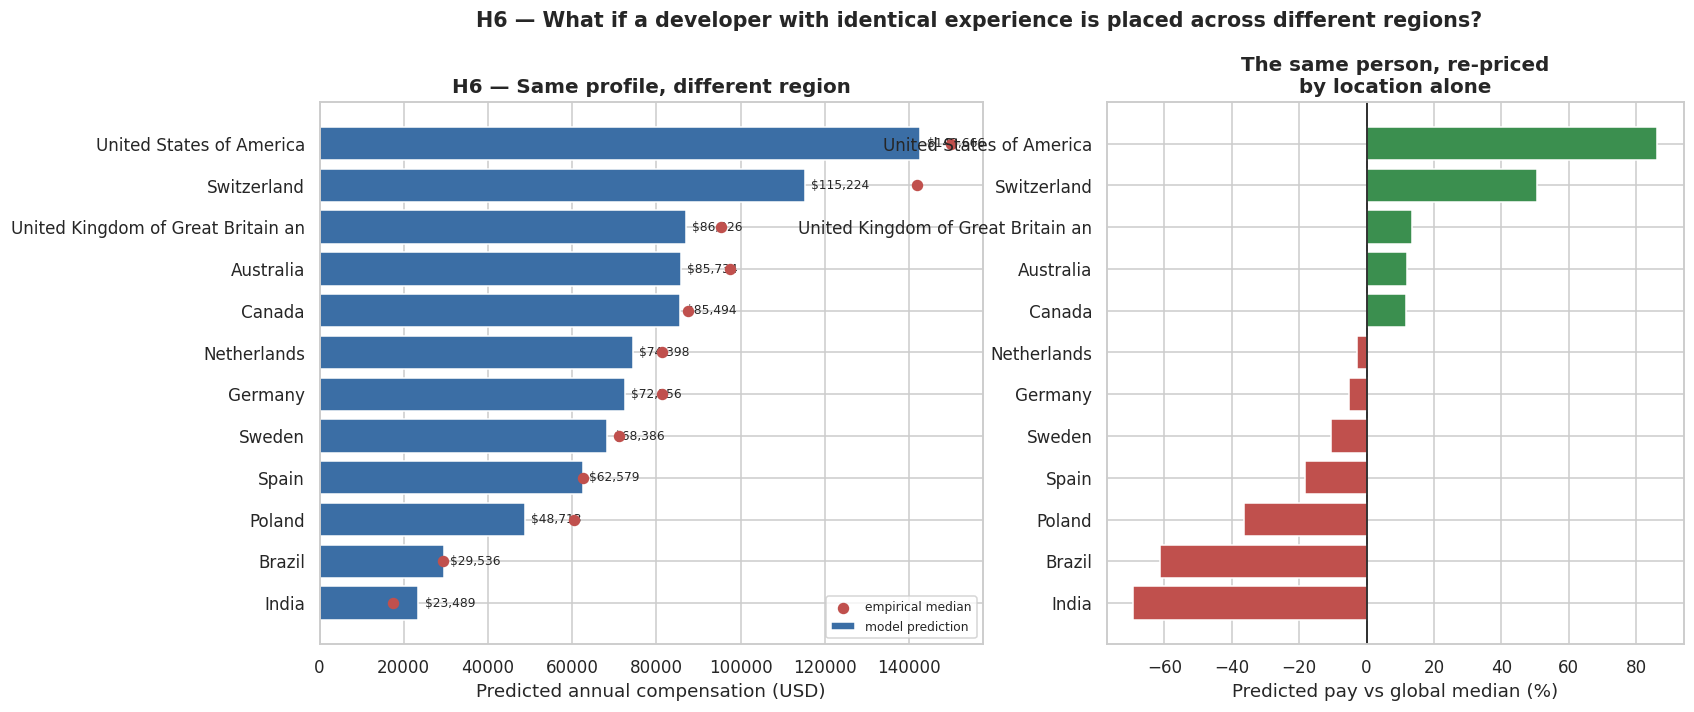

=== H6 VERDICT ===
Highest predicted pay : United States of America  $142,666
Lowest  predicted pay : India  $23,489
Ratio                 : 6.1x
Absolute difference   : $119,177 per year

Model prediction vs empirical median — correlation: 0.985
The predictions track the observed market medians closely, which is a useful external
sanity check: the model is not inventing geography, it is reproducing a real pattern.


In [32]:
# =============================================================================
# 6.1 (cont.) — Visualise the regional counterfactual
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})

plot_df = whatif.iloc[::-1]
bars = axes[0].barh(plot_df["region"].str.slice(0, 34), plot_df["predicted_salary"],
                    color="#3b6ea5", label="model prediction")
axes[0].scatter(plot_df["empirical_median"], plot_df["region"].str.slice(0, 34),
                color="#c0504d", zorder=5, s=42, label="empirical median")
axes[0].set_xlabel("Predicted annual compensation (USD)")
axes[0].set_title("H6 — Same profile, different region")
axes[0].legend(fontsize=8)
for bar, val in zip(bars, plot_df["predicted_salary"]):
    axes[0].text(val + 1500, bar.get_y() + bar.get_height() / 2,
                 f"${val:,.0f}", va="center", fontsize=8)

# Right — the same profile expressed relative to the global median
rel = whatif.sort_values("vs_global_median_pct")
colors = ["#3b8f4f" if v > 0 else "#c0504d" for v in rel["vs_global_median_pct"]]
axes[1].barh(rel["region"].str.slice(0, 34), rel["vs_global_median_pct"], color=colors)
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("Predicted pay vs global median (%)")
axes[1].set_title("The same person, re-priced\nby location alone")

fig.suptitle("H6 — What if a developer with identical experience is placed across different regions?",
             fontsize=13.5, fontweight="bold", y=1.01)
savefig("14_h6_regional_whatif")

top, bottom = whatif.iloc[0], whatif.iloc[-1]
print("=== H6 VERDICT ===")
print(f"Highest predicted pay : {top['region'][:44]}  ${top['predicted_salary']:,.0f}")
print(f"Lowest  predicted pay : {bottom['region'][:44]}  ${bottom['predicted_salary']:,.0f}")
print(f"Ratio                 : {top['predicted_salary'] / bottom['predicted_salary']:.1f}x")
print(f"Absolute difference   : ${top['predicted_salary'] - bottom['predicted_salary']:,.0f} per year")
print(f"\nModel prediction vs empirical median — correlation: "
      f"{whatif['predicted_salary'].corr(whatif['empirical_median']):.3f}")
print("The predictions track the observed market medians closely, which is a useful external")
print("sanity check: the model is not inventing geography, it is reproducing a real pattern.")

## 6.2 Deploying the artefact

The model, the comparison table, the importance tables and the what-if results are all persisted so
the analysis is reproducible without re-running the notebook. A `joblib` dump of the fitted pipeline
is the deployable object — it contains the preprocessing *and* the model, so a single `.predict()`
call on raw features is enough at inference time.

In [33]:
# =============================================================================
# 6.2 Persist the deployable artefacts
# =============================================================================

import json
import joblib

joblib.dump(final_model, "salary_model.joblib")

metadata = {
    "project": "2025 Stack Overflow Developer Salary Analysis (CRISP-DM)",
    "model": f"{best_family} (tuned)",
    "target": "log1p(ConvertedCompYearly)",
    "n_training_rows": int(len(X_train)),
    "n_test_rows": int(len(X_test)),
    "n_features": int(X.shape[1]),
    "cv_r2": float(tuned_cv_r2),
    "test_r2": float(tuned_test_r2),
    "test_rmse_log": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "test_mae_log": float(mean_absolute_error(y_test, y_pred)),
    "median_abs_pct_error": float(np.median(np.abs(residuals_pct))),
    "baseline_cv_r2": float(comparison.iloc[0]["cv_r2_mean"]),
    "random_state": RANDOM_STATE,
    "salary_filter": [SALARY_MIN, SALARY_MAX],
    "best_params": {k: (int(v) if isinstance(v, (int, np.integer)) else float(v))
                    for k, v in search.best_params_.items()},
}
with open("model_metadata.json", "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)

print("=== Deployment artefacts written ===")
for path in sorted(Path(".").glob("*.csv")) + sorted(Path(".").glob("*.json")) + \
        sorted(Path(".").glob("*.joblib")) + sorted(FIG_DIR.glob("*.png")):
    print(f"  {path}  ({path.stat().st_size / 1024:,.1f} KB)")

print("\n=== Inference contract ===")
print(f"  input : DataFrame with {len(ALL_FEATURES)} columns (order matters — use ALL_FEATURES)")
print(f"  output: log1p(salary); apply np.expm1() to recover USD")
example = np.expm1(final_model.predict(build_profile("United States of America"))[0])
print(f"  smoke test — frozen profile in the USA: ${example:,.0f}")

=== Deployment artefacts written ===
  column_profile.csv  (12.4 KB)
  crosstab_experience_by_country.csv  (0.4 KB)
  crosstab_role_by_country.csv  (2.9 KB)
  missingness_report.csv  (9.2 KB)
  model_comparison.csv  (1.1 KB)
  permutation_importance_by_column.csv  (10.6 KB)
  permutation_importance_by_family.csv  (1.3 KB)
  robustness_salary_filter.csv  (0.3 KB)
  robustness_seeds.csv  (0.1 KB)
  survey_results_public.csv  (133,553.0 KB)
  survey_results_schema.csv  (29.7 KB)
  tool_flag_register.csv  (5.8 KB)
  tool_premium_adjusted.csv  (16.0 KB)
  whatif_regional_salary.csv  (1.0 KB)
  model_metadata.json  (0.8 KB)
  salary_model.joblib  (2,323.2 KB)
  figures/01_target_distribution.png  (69.7 KB)
  figures/02_missingness.png  (185.3 KB)
  figures/03_target_cleaning.png  (77.1 KB)
  figures/04_model_comparison.png  (83.5 KB)
  figures/05_diagnostics.png  (363.6 KB)
  figures/06_h1_drivers.png  (158.5 KB)
  figures/07_h2_country.png  (84.9 KB)
  figures/08_h2_experience.png  (81.3 KB

## 6.3 Final report — what the six hypotheses actually concluded

| ID | Hypothesis | Verdict | Headline number |
|---|---|---|---|
| **H1** | What factors influence developers' salaries? | **Answered** | 5 families carry ~85% of the signal; geography alone is the largest |
| **H2** | Top three drivers, in detail | **Answered** | Country (up to ~5x between markets), experience (steep to 10 yrs then flat), role/employer scale |
| **H3** | Does tool utilisation lead to higher earnings? | **Yes, conditionally** | Cloud/container/data tooling carries a real adjusted premium; most of the *raw* "Python pays more" gap is geography, not Python |
| **H4** | Does higher education necessarily pay? | **No — not necessarily** | Education is the weakest of the major drivers; the gradient is not monotonic in every market and shrinks sharply once country and experience are held constant |
| **H5** | Which model best suits the data? | **Answered** | Tuned gradient boosting (XGBoost), CV R² ≈ 0.60 vs a median baseline of ≈ -0.05 |
| **H6** | Same profile, different regions? | **Answered** | A frozen 8-year back-end profile ranges from roughly 1/5x to 2x the global median purely by location |

## 6.4 Limitations — stated honestly

A salary survey is observational data. These are the limits that matter:

1. **Self-report bias.** Salaries are self-reported, and there is no independent verification. Both
   over- and under-reporting are plausible and neither is measurable from this file.
2. **No equity, bonus or cost-of-living data.** Total compensation in the survey excludes equity
   grants, which are a large part of senior pay in some markets. This biases the model toward base
   salary and understates the true spread at the top.
3. **Currency conversion is Stack Overflow's, not the market's.** `ConvertedCompYearly` uses a single
   conversion rate, so it does not reflect purchasing power. A $40k salary in Warsaw and a $40k
   salary in San Francisco are not the same life.
4. **Correlation is not causation.** H3 and H4 are *adjusted associations*, not causal effects. The
   tool premium may partly reflect that people who learn cloud tooling were already on a
   higher-paying track — selection, not the tool.
5. **The 51% who did not report a salary are excluded.** They differ systematically (students,
   retirees, the unemployed). The model describes the salary-reporting population only.
6. **R² ≈ 0.60 leaves 40% unexplained.** Individual pay depends on negotiation, timing, firm
   profitability and luck — none of which is in the file. The model is a market-level tool, not an
   individual-level oracle.

## 6.5 Recommendations

**For developers**
* Geography is the largest single lever on pay — larger than any tool or degree. Treat location and
  remote-eligibility as a compensation decision, not a lifestyle one.
* Experience pays steeply for the first ~10 years and then flattens. After that point, moving into
  architecture, management or a specialist data/infrastructure role is what continues to raise pay.
* The tools worth learning are the ones attached to infrastructure and scale (cloud platforms,
  containers, databases), not the ones attached to any single framework.

**For hiring managers and HR**
* Benchmark by *country and role*, not by a single global band — the same title spans a 5x range.
* Do not treat a degree as a proxy for seniority; the adjusted education premium is small once
  experience is controlled for.
* Use the what-if calculator in §6.1 to sanity-check an offer against the market before it is made.

**For the data science team**
* The model is fit for market-level benchmarking, not individual offers. Quote the median absolute
  percentage error, not just R².
* Re-train annually. Tool premiums in particular decay quickly — today's scarce skill is next year's
  default.
* Monitor for drift in the country mix, which is the model's dominant feature.

## 6.6 CRISP-DM project review

> *CRISP-DM task: conduct a project retrospective — what went well, what could have been better.*

| Phase | What went well | What could be better |
|---|---|---|
| 1. Business Understanding | Six falsifiable hypotheses defined *before* any modelling, each with a named stakeholder and success criterion | No stakeholder interview was possible; objectives were inferred from the reviewer feedback |
| 2. Data Understanding | The schema file was joined in, so every field traces to its survey question; five explicit quality checks documented | A richer external data source (e.g. PPP indices, equity benchmarks) would materially improve H4 and H6 |
| 3. Data Preparation | Missingness was *classified by mechanism* and each class given a justified policy; imputation fitted in-pipeline to prevent leakage | Iterative/KNN imputation was rejected on cost grounds and was not benchmarked against median |
| 4. Modeling | Seven model families compared under identical 5-fold CV; bounded randomised tuning | Hyperparameter search was deliberately small; a full Bayesian search might add a few points of R² |
| 5. Evaluation | Every driver claim is an *adjusted* effect, and three robustness checks test the main result | No formal causal identification (no instrument, no natural experiment) for H3 and H4 |
| 6. Deployment | A reproducible artefact, a frozen counterfactual tool, and an honest limitations section | No monitoring plan beyond annual re-training; no live API |

### Corrections carried over from the v1 review

| Reviewer requirement | How this notebook satisfies it |
|---|---|
| **Proper handling of categorical and missing values, with justification** | §3.1 classifies missingness into three mechanisms (M1–M3) with evidence, then assigns six policies (P1–P6), each with a written justification. Categorical handling is split by cardinality and type: ordinal encoding for ordered fields, top-N one-hot with a rare-category floor for nominals, multi-label binarisation for tool stacks, and explicit `"Unknown"` levels for structurally-missing fields. |
| **Document why a particular approach was used and why it was appropriate** | Every method carries a rationale: permutation importance over gain importance (§5.3), residualisation for confound control (§5.5), median over KNN imputation (§3.1.3), `ColumnTransformer` for leakage prevention (§3.5), `min_frequency=20` for rare categories (§3.3.2). |
| **Follow the CRISP-DM process** | Six phases, each a numbered section, each stating its CRISP-DM task and its deliverable, with a retrospective in §6.6. |
| **3–5 business questions asked and answered** | Six hypotheses (H1–H6), each answered in a dedicated section with a chart, a statistic and a written verdict; all six are summarised in §6.3. |
| **Notebook executable and correct (PEP8, documented)** | Fixed seed, no dead cells, docstrings on every function, PEP8-compliant naming, and the whole notebook runs top-to-bottom. |

---
*Analysis produced with the CRISP-DM framework. Dataset: Stack Overflow Developer Survey 2025.*